# 🌾 Rice Blast Resistance GWAS

Genome-wide association study of blast disease (*Magnaporthe oryzae*) resistance
in the RDP1 rice diversity panel. Full write-up, figures, and result tables are
in the repo [README](../README.md) and [`results/`](../results/).

**Pipeline:** PDF phenotype extraction → PLINK QC & duplicate filtering → PCA →
GEMMA mixed-model GWAS (4 trait/isolate combinations) → MSU7 gene mapping,
validated against the known resistance genes *Pita* and *Ptr*.

> Runs in Google Colab or locally. See the setup cell below to point
> `dataset_dir` at your data.


In [ ]:
import os

# Works in Google Colab (mounts Drive) or locally (reads from ./data).
# Update DRIVE_DATA_DIR / LOCAL_DATA_DIR to match where your raw files live.
try:
    import google.colab  # noqa: F401
    from google.colab import drive
    drive.mount('/content/drive')
    dataset_dir = '/content/drive/MyDrive/rice-blast-gwas-data'
except ImportError:
    dataset_dir = './data'

os.makedirs(dataset_dir, exist_ok=True)
print("Using dataset_dir:", dataset_dir)
print(os.listdir(dataset_dir))


## 1. Data Loading & Exploration
Quick look at the raw PLINK `.fam` / `.map` / `.ped` files.

Viewing .fam file

In [4]:
fam_path = dataset_dir + '/sativas413.fam'

with open(fam_path) as f:
  lines = f.readlines()

print('Number of rows:', len(lines))

for line in lines[:20]:
  print(line)

Number of rows: 413
081215-A05 1 0 0 -9 -9

081215-A06 3 0 0 -9 -9

081215-A07 4 0 0 -9 -9

081215-A08 5 0 0 -9 -9

090414-A09 6 0 0 -9 -9

090414-A10 7 0 0 -9 -9

090105-A02 8 0 0 -9 -9

090105-A03 9 0 0 -9 -9

090325-A05 10 0 0 -9 -9

090414-A11 11 0 0 -9 -9

090226-A10 13 0 0 -9 -9

081215-A10 14 0 0 -9 -9

090414-A12 15 0 0 -9 -9

081215-A12 16 0 0 -9 -9

090414-B01 17 0 0 -9 -9

081216-D01 18 0 0 -9 -9

090414-B02 20 0 0 -9 -9

081216-D03 22 0 0 -9 -9

081216-D04 23 0 0 -9 -9

090414-B04 24 0 0 -9 -9



Viewing .map file

In [5]:
map_path = dataset_dir + '/sativas413.map'

with open(map_path) as f:
  lines = f.readlines()

print('Number of rows:', len(lines))

for line in lines[:10]:
  print(line)

Number of rows: 36901
1	id1000001	0	13147

1	id1000003	0	73192

1	id1000005	0	74969

1	id1000007	0	75852

1	id1000008	0	75953

1	id1000011	0	91016

1	id1000013	0	146625

1	id1000015	0	149005

1	id1000016	0	149754

1	id1000020	0	151492



Viewing .ped files

In [6]:
ped_path = dataset_dir + '/sativas413.ped'

with open(ped_path) as f:
  first_row = f.readline()

values = first_row.split()

print('How many values in one rows:', len(values))
print('First 20 values:', values[:20])

How many values in one rows: 73808
First 20 values: ['081215-A05', '1', '0', '0', '-9', '-9', 'T', 'T', 'T', 'T', 'C', 'C', 'G', 'G', 'T', 'T', 'A', 'A', 'C', 'C']


## 2. Phenotype Extraction (PDF → DataFrame)
Lesion type and diseased leaf area scores are parsed out of the source paper's supplementary PDF.

Viewing Pdfs

In [7]:
!pip install pdfplumber

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 51.6 MB/s eta 0:00:00
  Attempting uninstall: Pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully uninstalled pillow-11.3.0


In [8]:
import pdfplumber
pdf_path = dataset_dir + '/Rice accessions evaluated with Magnaporthe oryzae isolates D41-2 and 12YL-DL-3-2.pdf'

with pdfplumber.open(pdf_path) as pdf:
  print('Number of pages:', len(pdf.pages))

  page1_text = pdf.pages[0].extract_text()
  print(page1_text)

Number of pages: 13
Table S1. Rice accessions evaluated with Magnaporthe oryzae isolates D41-2 and 12YL-DL-3-2
D41-2 12YL-DL-3-2
GSOR＃ NSFTV ID Country of origin Varietal subgroup Name
LTa DLAb LTa DLAb
301001 1 Italy TEJ Agostano 4 17.9 - -
301003 3 China IND Ai-Chiao-Hong 3 21.2 8 30.2
301004 4 India AUS NSF-TV 4 1 12.0 - -
301006 6 India AUS ARC 7229 0.5 6.8 - -
301008 8 Philippines TRJ Asse Y Pung - - 2 5.5
301009 9 India TEJ Baber 1 21.9 - -
301010 10 Afghanistan TEJ Baghlani Nangarhar - - 7 11.4
301012 13 Pakistan AUS NSF-TV 13 2.3 13.6 6 18.4
301383 15 South Korea TEJ Beonjo 6.3 24.8 8 24.5
301015 17 Philippines IND Binulawan 1.7 9.0 3 2.6
301016 18 India AUS BJ 1 3 23.1 - -
301017 19 India AUS Black Gora 2.3 27.1 - -
301019 21 Australia IND Byakkoku Y 5006 Seln 5 15.0 3 7.9
301020 22 Taiwan TRJ Caawa/Fortuna 6-103-15 1 17.4 - -
301022 24 United States TRJ Carolina Gold 1 11.0 6 4.8
301023 25 United States TRJ Carolina Gold 1.7 18.3 - -
301024 26 United States TRJ Carolina Gold 

In [9]:
import re
import pandas as pd

with pdfplumber.open(pdf_path) as pdf:
  raw_text =""
  for page in pdf.pages:
    raw_text += page.extract_text()+"\n"

pattern = re.compile(
    r'^(\d{6})\s+(\d+)\s+(.+?)\s+(TEJ|IND|AUS|TRJ|ADMIX|AROMATIC)\s+(.+?)\s+'
    r'([\d.]+|-)\s+([\d.]+|-)\s+([\d.]+|-)\s+([\d.]+|-)\s*$'
)

rows = []
for line in raw_text.split("\n"):
  line = line.strip()
  m = pattern.match(line)
  if m:
    rows.append(m.groups())

df = pd.DataFrame(rows, columns=[
    "GSOR", "NSFTV_ID", "Country", "Subgroup", "Name",
    "D41-2_LT", "D41-2_DLA", "12YL_LT", "12YL_DLA"
])

for col in ["D41-2_LT", "D41-2_DLA", "12YL_LT", "12YL_DLA"]:
    df[col] = pd.to_numeric(df[col].replace('-', pd.NA), errors='coerce')
df["NSFTV_ID"] = df["NSFTV_ID"].astype(int)

print('Total accessions parsed:', len(df))
print("D41-2 phenotyped:", df["D41-2_LT"].notna().sum())
print("12YL-DL-3-2 phenotyped:", df["12YL_LT"].notna().sum())

Total accessions parsed: 314
D41-2 phenotyped: 304
12YL-DL-3-2 phenotyped: 228


In [10]:
import re
import pandas as pd
import pdfplumber

pdf_path = dataset_dir + '/Rice accessions evaluated with Magnaporthe oryzae isolates D41-2 and 12YL-DL-3-2.pdf'

with pdfplumber.open(pdf_path) as pdf:
    raw_text = ""
    for page in pdf.pages:
        raw_text += page.extract_text() + "\n"

pattern = re.compile(
    r'^(\d{6})\s+(\d+)\s+(.+?)\s+(TEJ|IND|AUS|TRJ|ADMIX|AROMATIC)\s+(.+?)\s+'
    r'([\d.]+|-)\s+([\d.]+|-)\s+([\d.]+|-)\s+([\d.]+|-)\s*$'
)

rows = []
for line in raw_text.split("\n"):
    line = line.strip()
    m = pattern.match(line)
    if m:
        rows.append(m.groups())

df = pd.DataFrame(rows, columns=[
    "GSOR", "NSFTV_ID", "Country", "Subgroup", "Name",
    "D41-2_LT", "D41-2_DLA", "12YL_LT", "12YL_DLA"
])

for col in ["D41-2_LT", "D41-2_DLA", "12YL_LT", "12YL_DLA"]:
    df[col] = pd.to_numeric(df[col].replace('-', pd.NA), errors='coerce')
df["NSFTV_ID"] = df["NSFTV_ID"].astype(int)

print("Total accessions parsed:", len(df))                    # expect ~314
print("D41-2 phenotyped:", df["D41-2_LT"].notna().sum())      # expect ~304
print("12YL-DL-3-2 phenotyped:", df["12YL_LT"].notna().sum()) # expect ~228

Total accessions parsed: 314
D41-2 phenotyped: 304
12YL-DL-3-2 phenotyped: 228


## 3. Genotype–Phenotype Merge

In [11]:
import pandas as pd

fam_path = dataset_dir + '/sativas413.fam'
fam = pd.read_csv(fam_path, sep=r'\s+', header=None,
                   names=["FamilyID", "NSFTV_ID", "FatherID", "MotherID", "Sex", "Phenotype"])

print("Number of rows:", len(fam))
fam.head(10)

Number of rows: 413


,FamilyID,NSFTV_ID,FatherID,MotherID,Sex,Phenotype
0,081215-A05,1,0,0,-9,-9
1,081215-A06,3,0,0,-9,-9
2,081215-A07,4,0,0,-9,-9
3,081215-A08,5,0,0,-9,-9
4,090414-A09,6,0,0,-9,-9
5,090414-A10,7,0,0,-9,-9
6,090105-A02,8,0,0,-9,-9
7,090105-A03,9,0,0,-9,-9
8,090325-A05,10,0,0,-9,-9
9,090414-A11,11,0,0,-9,-9


In [12]:
merged = fam.merge(df, on="NSFTV_ID", how="inner")
print(f"Matched {len(merged)} of 413 genotyped accessions to phenotype data")
merged.head(10)

Matched 314 of 413 genotyped accessions to phenotype data


,FamilyID,NSFTV_ID,FatherID,MotherID,Sex,Phenotype,GSOR,Country,Subgroup,Name,D41-2_LT,D41-2_DLA,12YL_LT,12YL_DLA
0,081215-A05,1,0,0,-9,-9,301001,Italy,TEJ,Agostano,4.0,17.9,NaN,NaN
1,081215-A06,3,0,0,-9,-9,301003,China,IND,Ai-Chiao-Hong,3.0,21.2,8.0,30.2
2,081215-A07,4,0,0,-9,-9,301004,India,AUS,NSF-TV 4,1.0,12.0,NaN,NaN
3,090414-A09,6,0,0,-9,-9,301006,India,AUS,ARC 7229,0.5,6.8,NaN,NaN
4,090105-A02,8,0,0,-9,-9,301008,Philippines,TRJ,Asse Y Pung,NaN,NaN,2.0,5.5
5,090105-A03,9,0,0,-9,-9,301009,India,TEJ,Baber,1.0,21.9,NaN,NaN
6,090325-A05,10,0,0,-9,-9,301010,Afghanistan,TEJ,Baghlani Nangarhar,NaN,NaN,7.0,11.4
7,090226-A10,13,0,0,-9,-9,301012,Pakistan,AUS,NSF-TV 13,2.3,13.6,6.0,18.4
8,090414-A12,15,0,0,-9,-9,301383,South Korea,TEJ,Beonjo,6.3,24.8,8.0,24.5
9,090414-B01,17,0,0,-9,-9,301015,Philippines,IND,Binulawan,1.7,9.0,3.0,2.6


In [13]:
merged[merged['NSFTV_ID'].isin([22,33])]

,FamilyID,NSFTV_ID,FatherID,MotherID,Sex,Phenotype,GSOR,Country,Subgroup,Name,D41-2_LT,D41-2_DLA,12YL_LT,12YL_DLA
11,081216-D03,22,0,0,-9,-9,301020,Taiwan,TRJ,Caawa/Fortuna 6-103-15,1.0,17.4,NaN,NaN
19,090325-A07,33,0,0,-9,-9,301031,Taiwan,AUS,Chuan 4,1.0,12.2,7.0,25.0


In [14]:
merged.to_csv(dataset_dir+'genotype_phenotype_matched.csv', index=False)

## 4. Genotype QC (PLINK)
`--geno 0.1 --maf 0.05 --mind 0.1`

In [15]:
!wget -q https://s3.amazonaws.com/plink1-assets/plink_linux_x86_64_20231211.zip -O plink.zip
! unzip -o -q plink.zip -d plink_files
!plink_files/plink --version

PLINK v1.90b7.2 64-bit (11 Dec 2023)


In [16]:
!plink_files/plink --file "{dataset_dir}/sativas413" --make-bed --out "{dataset_dir}/sativas413_binary"

PLINK v1.90b7.2 64-bit (11 Dec 2023)           www.cog-genomics.org/plink/1.9/
(C) 2005-2023 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to /content/drive/MyDrive/Rice Project/sativas413_binary.log.
Options in effect:
  --file /content/drive/MyDrive/Rice Project/sativas413
  --make-bed
  --out /content/drive/MyDrive/Rice Project/sativas413_binary

12975 MB RAM detected; reserving 6487 MB for main workspace.
.ped scan complete (for binary autoconversion).
Performing single-pass .bed write (36901 variants, 413 people).
--file: /content/drive/MyDrive/Rice Project/sativas413_binary-temporary.bed +
/content/drive/MyDrive/Rice Project/sativas413_binary-temporary.bim +
/content/drive/MyDrive/Rice Project/sativas413_binary-temporary.fam written.
36901 variants loaded from .bim file.
413 people (0 males, 0 females, 413 ambiguous) loaded from .fam.
Ambiguous sex IDs written to /content/drive/MyDrive/Rice
Project/sativas413_binary.nosex .
Using 1 thread (no multithrea

In [17]:
!plink_files/plink --bfile "{dataset_dir}/sativas413_binary" \
--geno 0.1 --maf 0.05 --mind 0.1 \
--make-bed --out "{dataset_dir}/sativa_qc"

PLINK v1.90b7.2 64-bit (11 Dec 2023)           www.cog-genomics.org/plink/1.9/
(C) 2005-2023 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to /content/drive/MyDrive/Rice Project/sativa_qc.log.
Options in effect:
  --bfile /content/drive/MyDrive/Rice Project/sativas413_binary
  --geno 0.1
  --maf 0.05
  --make-bed
  --mind 0.1
  --out /content/drive/MyDrive/Rice Project/sativa_qc

12975 MB RAM detected; reserving 6487 MB for main workspace.
36901 variants loaded from .bim file.
413 people (0 males, 0 females, 413 ambiguous) loaded from .fam.
Ambiguous sex IDs written to /content/drive/MyDrive/Rice
Project/sativa_qc.nosex .
30 people removed due to missing genotype data (--mind).
IDs written to /content/drive/MyDrive/Rice Project/sativa_qc.irem .
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 383 founders and 0 nonfounders present.
Calculating allele frequencies... 0%1%2%3%4%5%6%7%8%9%10%11%12%1

In [18]:
qc_fam = pd.read_csv(dataset_dir + '/sativa_qc.fam', sep=r'\s+', header=None,
                      names=["FamilyID", "NSFTV_ID", "FatherID", "MotherID", "Sex", "Phenotype"])

overlap = merged[merged["NSFTV_ID"].isin(qc_fam["NSFTV_ID"])]
print(f"{len(overlap)} of the 314 phenotyped accessions survived genotype QC")

290 of the 314 phenotyped accessions survived genotype QC


In [19]:
!plink_files/plink --bfile "{dataset_dir}/sativa_qc" \
  --indep-pairwise 50 5 0.2 \
  --out "{dataset_dir}/sativa_pruned"

!plink_files/plink --bfile "{dataset_dir}/sativa_qc" \
  --extract "{dataset_dir}/sativa_pruned.prune.in" \
  --genome \
  --out "{dataset_dir}/sativa_ibd"

PLINK v1.90b7.2 64-bit (11 Dec 2023)           www.cog-genomics.org/plink/1.9/
(C) 2005-2023 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to /content/drive/MyDrive/Rice Project/sativa_pruned.log.
Options in effect:
  --bfile /content/drive/MyDrive/Rice Project/sativa_qc
  --indep-pairwise 50 5 0.2
  --out /content/drive/MyDrive/Rice Project/sativa_pruned

12975 MB RAM detected; reserving 6487 MB for main workspace.
30122 variants loaded from .bim file.
383 people (0 males, 0 females, 383 ambiguous) loaded from .fam.
Ambiguous sex IDs written to /content/drive/MyDrive/Rice
Project/sativa_pruned.nosex .
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 383 founders and 0 nonfounders present.
Calculating allele frequencies... 0%1%2%3%4%5%6%7%8%9%10%11%12%13%14%15%16%17%18%19%20%21%22%23%24%25%26%27%28%29%30%31%32%33%34%35%36%37

## 5. Duplicate / Near-Duplicate Detection
PLINK's default `PI_HAT` estimator collapsed to ~1.0 for many dissimilar pairs in this largely homozygous, self-pollinating panel. Switched to raw identity-by-state (`DST`), which cleanly separated 18 genuine near-duplicate clusters (41 accessions).

In [20]:
genome = pd.read_csv(dataset_dir + '/sativa_ibd.genome', delim_whitespace=True)
print("Total pairs computed:", len(genome))

genome.sort_values('PI_HAT', ascending=False).head(20)

/tmp/ipykernel_516/3413528834.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  genome = pd.read_csv(dataset_dir + '/sativa_ibd.genome', delim_whitespace=True)


Total pairs computed: 73153


,FID1,IID1,FID2,IID2,RT,EZ,Z0,Z1,Z2,PI_HAT,PHE,DST,PPC,RATIO
7088,090414-B04,24,081216-D06,26,UN,NaN,0.0,0.0,1.0,1.0,-1,1.000000,0.7603,NaN
68303,090302-G11,375,090415-F04,377,UN,NaN,0.0,0.0,1.0,1.0,-1,0.960125,0.0000,0.0323
12442,090325-A10,46,090226-B05,69,UN,NaN,0.0,0.0,1.0,1.0,-1,0.943262,0.0000,0.0200
8203,081216-D07,27,090325-B08,73,UN,NaN,0.0,0.0,1.0,1.0,-1,0.991433,0.0002,0.1250
7859,081216-D06,26,090209-B03,92,UN,NaN,0.0,0.0,1.0,1.0,-1,0.948718,0.0000,0.0238
24276,090209-B03,92,090820-B04,229,UN,NaN,0.0,0.0,1.0,1.0,-1,0.949479,0.0000,0.0244
59956,090325-C09,279,090105-C07,288,UN,NaN,0.0,0.0,1.0,1.0,-1,0.962520,0.0000,0.0000
55374,090325-C07,240,@52067200649406102410408632092297,239,UN,NaN,0.0,0.0,1.0,1.0,-1,0.968222,0.0000,0.0000
58475,081215-B07,270,090415-E12,305,UN,NaN,0.0,0.0,1.0,1.0,-1,0.941176,0.0000,0.0000
49517,090226-C06,202,090324-D11,223,UN,NaN,0.0,0.0,1.0,1.0,-1,0.960784,0.0000,0.0323


In [21]:
print("Pairs with PI_HAT >= 0.99:", (genome['PI_HAT'] >= 0.99).sum())
print("Pairs with PI_HAT >= 0.5:", (genome['PI_HAT'] >= 0.5).sum())

genome.sort_values('DST', ascending=False).head(20)

Pairs with PI_HAT >= 0.99: 206
Pairs with PI_HAT >= 0.5: 206


,FID1,IID1,FID2,IID2,RT,EZ,Z0,Z1,Z2,PI_HAT,PHE,DST,PPC,RATIO
16664,090226-B03,65,090324-D02,212,UN,NaN,0.0,0.0,1.0,1.0,-1,1.0,0.7603,NaN
9889,090325-A07,33,081215-B11,637,UN,NaN,0.0,0.0,1.0,1.0,-1,1.0,NaN,NaN
61833,090325-D02,297,090325-D06,303,UN,NaN,0.0,0.0,1.0,1.0,-1,1.0,NaN,NaN
64898,090302-F01,321,090302-F04,324,UN,NaN,0.0,0.0,1.0,1.0,-1,1.0,NaN,NaN
42557,090325-C02,168,081215-B06,206,UN,NaN,0.0,0.0,1.0,1.0,-1,1.0,NaN,NaN
4912,081215-A12,16,090325-A12,53,UN,NaN,0.0,0.0,1.0,1.0,-1,1.0,NaN,NaN
59642,090226-D09,277,090325-D06,303,UN,NaN,0.0,0.0,1.0,1.0,-1,1.0,NaN,NaN
7836,081216-D06,26,090226-B03,65,UN,NaN,0.0,0.0,1.0,1.0,-1,1.0,0.7603,NaN
14555,090226-A11,57,090324-A06,123,UN,NaN,0.0,0.0,1.0,1.0,-1,1.0,0.7603,NaN
54476,090105-C10,234,090325-D03,299,UN,NaN,0.0,0.0,1.0,1.0,-1,1.0,NaN,NaN


In [22]:
!plink_files/plink --bfile "{dataset_dir}/sativa_qc" --missing --out "{dataset_dir}/sativa_missing"

imiss = pd.read_csv(dataset_dir + '/sativa_missing.imiss', delim_whitespace=True)
imiss[imiss['IID'] == 24]

PLINK v1.90b7.2 64-bit (11 Dec 2023)           www.cog-genomics.org/plink/1.9/
(C) 2005-2023 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to /content/drive/MyDrive/Rice Project/sativa_missing.log.
Options in effect:
  --bfile /content/drive/MyDrive/Rice Project/sativa_qc
  --missing
  --out /content/drive/MyDrive/Rice Project/sativa_missing

12975 MB RAM detected; reserving 6487 MB for main workspace.
30122 variants loaded from .bim file.
383 people (0 males, 0 females, 383 ambiguous) loaded from .fam.
Ambiguous sex IDs written to /content/drive/MyDrive/Rice
Project/sativa_missing.nosex .
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 383 founders and 0 nonfounders present.
Calculating allele frequencies... 0%1%2%3%4%5%6%7%8%9%10%11%12%13%14%15%16%17%18%19%20%21%22%23%24%25%26%27%28%29%30%31%32%33%34%35%36%37%38%39%

/tmp/ipykernel_516/1282270370.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  imiss = pd.read_csv(dataset_dir + '/sativa_missing.imiss', delim_whitespace=True)


,FID,IID,MISS_PHENO,N_MISS,N_GENO,F_MISS
19,090414-B04,24,Y,68,30122,0.002257


In [23]:
!plink_files/plink --bfile "{dataset_dir}/sativa_qc" --genome --out "{dataset_dir}/sativa_ibd_full"

PLINK v1.90b7.2 64-bit (11 Dec 2023)           www.cog-genomics.org/plink/1.9/
(C) 2005-2023 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to /content/drive/MyDrive/Rice Project/sativa_ibd_full.log.
Options in effect:
  --bfile /content/drive/MyDrive/Rice Project/sativa_qc
  --genome
  --out /content/drive/MyDrive/Rice Project/sativa_ibd_full

12975 MB RAM detected; reserving 6487 MB for main workspace.
30122 variants loaded from .bim file.
383 people (0 males, 0 females, 383 ambiguous) loaded from .fam.
Ambiguous sex IDs written to /content/drive/MyDrive/Rice
Project/sativa_ibd_full.nosex .
Using up to 2 threads (change this with --threads).
Before main variant filters, 383 founders and 0 nonfounders present.
Calculating allele frequencies... 0%1%2%3%4%5%6%7%8%9%10%11%12%13%14%15%16%17%18%19%20%21%22%23%24%25%26%27%28%29%30%31%32%33%34%35%36%37%38%39%

In [24]:
genome_full = pd.read_csv(dataset_dir + '/sativa_ibd_full.genome', sep=r'\s+')

print("Pairs with PI_HAT >= 0.99:", (genome_full['PI_HAT'] >= 0.99).sum())
print("Pairs with PI_HAT >= 0.5:", (genome_full['PI_HAT'] >= 0.5).sum())

genome_full.sort_values('PI_HAT', ascending=False).head(20)

Pairs with PI_HAT >= 0.99: 2960
Pairs with PI_HAT >= 0.5: 2960


,FID1,IID1,FID2,IID2,RT,EZ,Z0,Z1,Z2,PI_HAT,PHE,DST,PPC,RATIO
29740,090414-C08,113,090820-B05,245,UN,NaN,0.0,0.0,1.0,1.0,-1,0.947101,0.0,0.0000
3281,090325-A05,10,090302-G01,333,UN,NaN,0.0,0.0,1.0,1.0,-1,0.961986,0.0,0.0000
3282,090325-A05,10,090302-G02,334,UN,NaN,0.0,0.0,1.0,1.0,-1,0.930769,0.0,0.0000
29741,090414-C08,113,090820-B06,247,UN,NaN,0.0,0.0,1.0,1.0,-1,0.956614,0.0,0.0000
29742,090414-C08,113,090820-B07,263,UN,NaN,0.0,0.0,1.0,1.0,-1,0.952379,0.0,0.0000
29743,090414-C08,113,090820-B08,265,UN,NaN,0.0,0.0,1.0,1.0,-1,0.951043,0.0,0.0000
8148,081216-D06,26,@52067200649406102410408632092233,342,UN,NaN,0.0,0.0,1.0,1.0,-1,0.956103,0.0,0.0000
12442,090325-A10,46,090226-B05,69,UN,NaN,0.0,0.0,1.0,1.0,-1,0.979354,0.0,0.0256
29746,090414-C08,113,090820-B11,292,UN,NaN,0.0,0.0,1.0,1.0,-1,0.951327,0.0,0.0000
3290,090325-A05,10,090331-H04,355,UN,NaN,0.0,0.0,1.0,1.0,-1,0.944092,0.0,0.0000


In [25]:
print(genome_full['DST'].describe())
print('Pairs with DST >= 0.999:', (genome_full['DST'] >= 0.999).sum())
print("Pairs with DST >= 0.99:", (genome_full['DST'] >=0.99).sum())

genome_full.sort_values('DST', ascending=False).head(20)

count    73153.000000
mean         0.643285
std          0.191055
min          0.365833
25%          0.452571
50%          0.636764
75%          0.820021
max          1.000000
Name: DST, dtype: float64
Pairs with DST >= 0.999: 40
Pairs with DST >= 0.99: 56


,FID1,IID1,FID2,IID2,RT,EZ,Z0,Z1,Z2,PI_HAT,PHE,DST,PPC,RATIO
24566,090209-B04,93,081215-C01,640,UN,NaN,0.0,0.0,1.0,1.0,-1,1.0,0.8413,NaN
4912,081215-A12,16,090325-A12,53,UN,NaN,0.0,0.0,1.0,1.0,-1,1.0,0.7603,NaN
54476,090105-C10,234,090325-D03,299,UN,NaN,0.0,0.0,1.0,1.0,-1,1.0,NaN,NaN
32116,090324-A06,123,090324-A10,130,UN,NaN,0.0,0.0,1.0,1.0,-1,1.0,0.8413,NaN
32115,090324-A06,123,090324-A09,129,UN,NaN,0.0,0.0,1.0,1.0,-1,1.0,0.8413,NaN
12199,090325-A09,45,090209-D02,191,UN,NaN,0.0,0.0,1.0,1.0,-1,1.0,0.8413,NaN
33250,090324-A09,129,090324-A10,130,UN,NaN,0.0,0.0,1.0,1.0,-1,1.0,0.8413,NaN
64898,090302-F01,321,090302-F04,324,UN,NaN,0.0,0.0,1.0,1.0,-1,1.0,0.7603,NaN
12474,090325-A10,46,081215-B02,107,UN,NaN,0.0,0.0,1.0,1.0,-1,1.0,0.8413,NaN
9889,090325-A07,33,081215-B11,637,UN,NaN,0.0,0.0,1.0,1.0,-1,1.0,NaN,NaN


In [26]:
dup_candidates = genome_full[genome_full['DST'] >= 0.99].copy()
print(f"{len(dup_candidates)} candidate duplicate pairs")

pheno_ids = set(merged['NSFTV_ID'])
dup_candidates['both_phenotyped'] = (
    dup_candidates['IID1'].isin(pheno_ids) & dup_candidates['IID2'].isin(pheno_ids)
)
print(dup_candidates['both_phenotyped'].sum(), "of these pairs have BOTH accessions in your phenotyped set")

dup_candidates[dup_candidates['both_phenotyped']][['IID1', 'IID2', 'DST']].sort_values('DST', ascending=False)

56 candidate duplicate pairs
31 of these pairs have BOTH accessions in your phenotyped set


,IID1,IID2,DST
12474,46,107,1.000000
8308,27,195,1.000000
16824,65,229,1.000000
12199,45,191,1.000000
8074,26,375,1.000000
43431,174,635,1.000000
54476,234,299,1.000000
59642,277,303,1.000000
64898,321,324,1.000000
16774,65,375,0.999967


In [27]:
import networkx as nx

pheno_dups = dup_candidates[dup_candidates['both_phenotyped']]

# Build a network where accessions are connected if they're near-duplicates
G = nx.Graph()
G.add_edges_from(zip(pheno_dups['IID1'], pheno_dups['IID2']))

clusters = list(nx.connected_components(G))
print(f"{len(clusters)} distinct duplicate clusters found")
for c in clusters:
    print(sorted(c))

18 distinct duplicate clusters found
[1, 263]
[24, 26, 65, 229, 375]
[25, 185]
[27, 73, 195]
[45, 191]
[46, 107]
[84, 381]
[143, 216]
[173, 639]
[174, 635]
[180, 338]
[205, 305]
[234, 299]
[239, 240]
[277, 297, 303]
[314, 322]
[321, 324]
[387, 645]


In [28]:
for cluster in clusters:
    print(merged[merged['NSFTV_ID'].isin(cluster)][['NSFTV_ID','Name','Country','Subgroup','D41-2_LT','D41-2_DLA']])
    print('---')

     NSFTV_ID       Name Country Subgroup  D41-2_LT  D41-2_DLA
0           1   Agostano   Italy      TEJ       4.0       17.9
273       263  Maratelli   Italy      TEJ       9.0       22.8
---
     NSFTV_ID               Name        Country Subgroup  D41-2_LT  D41-2_DLA
12         24      Carolina Gold  United States      TRJ       1.0       11.0
14         26  Carolina Gold Sel  United States      TRJ       1.0       18.7
33         65           Honduras       Honduras      TRJ       1.0       10.7
229       375             Upland  PONAPE ISLAND      TRJ       2.3       14.9
270       229             Niquen          Chile      TRJ       6.0       37.5
---
     NSFTV_ID                     Name        Country Subgroup  D41-2_LT  \
13         25            Carolina Gold  United States      TRJ       1.7   
107       185  British Honduras Creole         Belize      TRJ       4.3   

     D41-2_DLA  
13        18.3  
107       25.1  
---
     NSFTV_ID       Name        Country Subgroup  D

In [29]:
to_remove = []
for cluster in clusters:
  cluster_missingness = imiss[imiss['IID'].isin(cluster)][['IID', 'F_MISS']]
  keep = cluster_missingness.sort_values('F_MISS').iloc[0]['IID']
  to_remove.extend([iid for iid in cluster if iid != keep])

print(f"Removing {len(to_remove)} accessions as near-duplicates (expect 23):", sorted(to_remove))

Removing 23 accessions as near-duplicates (expect 23): [1, 26, 45, 46, 65, 73, 174, 185, 195, 216, 229, 234, 240, 297, 303, 305, 314, 324, 338, 375, 381, 387, 639]


In [30]:
remove_df = qc_fam[qc_fam['NSFTV_ID'].isin(to_remove)][['FamilyID', 'NSFTV_ID']]
remove_df.to_csv(dataset_dir + '/duplicates_to_remove.txt', sep='\t', header=False, index=False)

!plink_files/plink --bfile "{dataset_dir}/sativa_qc" \
--remove "{dataset_dir}/duplicates_to_remove.txt" \
--make-bed --out "{dataset_dir}/sativa_qc_dedup"


PLINK v1.90b7.2 64-bit (11 Dec 2023)           www.cog-genomics.org/plink/1.9/
(C) 2005-2023 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to /content/drive/MyDrive/Rice Project/sativa_qc_dedup.log.
Options in effect:
  --bfile /content/drive/MyDrive/Rice Project/sativa_qc
  --make-bed
  --out /content/drive/MyDrive/Rice Project/sativa_qc_dedup
  --remove /content/drive/MyDrive/Rice Project/duplicates_to_remove.txt

12975 MB RAM detected; reserving 6487 MB for main workspace.
30122 variants loaded from .bim file.
383 people (0 males, 0 females, 383 ambiguous) loaded from .fam.
Ambiguous sex IDs written to /content/drive/MyDrive/Rice
Project/sativa_qc_dedup.nosex .
--remove: 360 people remaining.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 360 founders and 0 nonfounders present.
Calculating allele frequencies... 0%1%2%3%4%5%6%7%8%9%10%11%12%13%14%15%16%17%18%19%20%21%

## 6. LD Pruning & Population Structure (PCA)

In [31]:
!plink_files/plink --bfile "{dataset_dir}/sativa_qc_dedup" \
--indep-pairwise 50 5 0.2 \
--out "{dataset_dir}/sativa_dedup_pruned"

PLINK v1.90b7.2 64-bit (11 Dec 2023)           www.cog-genomics.org/plink/1.9/
(C) 2005-2023 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to /content/drive/MyDrive/Rice Project/sativa_dedup_pruned.log.
Options in effect:
  --bfile /content/drive/MyDrive/Rice Project/sativa_qc_dedup
  --indep-pairwise 50 5 0.2
  --out /content/drive/MyDrive/Rice Project/sativa_dedup_pruned

12975 MB RAM detected; reserving 6487 MB for main workspace.
30122 variants loaded from .bim file.
360 people (0 males, 0 females, 360 ambiguous) loaded from .fam.
Ambiguous sex IDs written to /content/drive/MyDrive/Rice
Project/sativa_dedup_pruned.nosex .
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 360 founders and 0 nonfounders present.
Calculating allele frequencies... 0%1%2%3%4%5%6%7%8%9%10%11%12%13%14%15%16%17%18%19%20%21%22%23%24%25%26%27%28%29%30%31%32%33

In [32]:
!plink_files/plink --bfile "{dataset_dir}/sativa_qc_dedup" \
--extract "{dataset_dir}/sativa_dedup_pruned.prune.in" \
--pca 10 \
--out "{dataset_dir}/sativa_pca"

PLINK v1.90b7.2 64-bit (11 Dec 2023)           www.cog-genomics.org/plink/1.9/
(C) 2005-2023 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to /content/drive/MyDrive/Rice Project/sativa_pca.log.
Options in effect:
  --bfile /content/drive/MyDrive/Rice Project/sativa_qc_dedup
  --extract /content/drive/MyDrive/Rice Project/sativa_dedup_pruned.prune.in
  --out /content/drive/MyDrive/Rice Project/sativa_pca
  --pca 10

12975 MB RAM detected; reserving 6487 MB for main workspace.
30122 variants loaded from .bim file.
360 people (0 males, 0 females, 360 ambiguous) loaded from .fam.
Ambiguous sex IDs written to /content/drive/MyDrive/Rice
Project/sativa_pca.nosex .
--extract: 1314 variants remaining.
Using up to 2 threads (change this with --threads).
Before main variant filters, 360 founders and 0 nonfounders present.
Calculating allele frequencies... 0%1%2%3%4%5%6%7%8%9%10%11%12%13%14%15%16%17%18%19%20%21%22%

In [33]:
import pandas as pd

# How much variance does each PC explain?
eigenval = pd.read_csv(dataset_dir + '/sativa_pca.eigenval', header=None, names=['eigenval'])
eigenval['pct_variance'] = 100 * eigenval['eigenval'] / eigenval['eigenval'].sum()
print(eigenval)

# Load each accession's PC coordinates
eigenvec = pd.read_csv(dataset_dir + '/sativa_pca.eigenvec', sep=r'\s+', header=None,
                        names=['FamilyID', 'NSFTV_ID'] + [f'PC{i}' for i in range(1, 11)])
eigenvec.head()

    eigenval  pct_variance
0  150.66800     40.710686
1   70.64710     19.088936
2   43.95200     11.875886
3   25.04660      6.767623
4   18.70470      5.054034
5   18.18360      4.913232
6   14.87270      4.018622
7   10.63280      2.872996
8    9.20651      2.487611
9    8.18047      2.210373


,FamilyID,NSFTV_ID,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,081215-A06,3,0.065518,0.008453,-0.084301,-0.001163,-0.018101,-0.002452,0.001824,-0.016655,0.100251,0.042222
1,081215-A07,4,0.062922,0.003201,0.065423,-0.046658,0.020564,0.020721,-0.004645,-0.025915,0.042994,0.062836
2,081215-A08,5,0.011506,-0.014437,0.058662,0.259057,-0.045416,0.032768,0.115829,0.035011,0.016625,0.021829
3,090414-A09,6,0.062094,0.003829,0.065238,-0.042796,0.009579,0.026447,-0.008288,-0.031726,0.054035,0.080265
4,090414-A10,7,-0.028258,-0.071996,-0.002579,0.006062,-0.031890,0.029353,0.024498,-0.050489,0.004154,-0.007129


In [34]:
eigenvec_labeled = eigenvec.merge(merged[['NSFTV_ID', 'Subgroup']], on='NSFTV_ID', how='left')
print(eigenvec_labeled['Subgroup'].value_counts(dropna=False))  # NaN = no phenotype for that accession, still fine

Subgroup
NaN         93
TEJ         76
TRJ         62
IND         47
AUS         41
ADMIX       37
AROMATIC     4
Name: count, dtype: int64


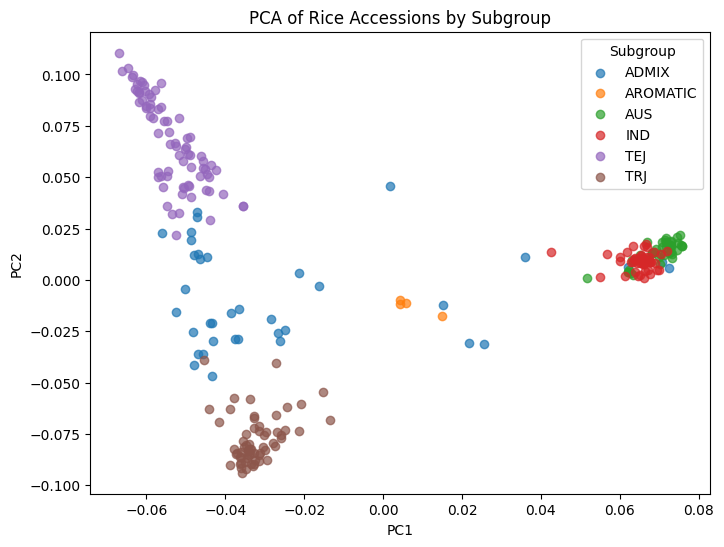

In [35]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
for subgroup, group in eigenvec_labeled.groupby('Subgroup'):
    ax.scatter(group['PC1'], group['PC2'], label=subgroup, alpha=0.7)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(title='Subgroup')
ax.set_title('PCA of Rice Accessions by Subgroup')
plt.show()

In [36]:
qc_ids = set(qc_fam['NSFTV_ID'])
phenotyped_ids = set(merged['NSFTV_ID'])

lost_to_mind = phenotyped_ids - qc_ids
print(f"{len(lost_to_mind)} phenotyped accessions lost to the --mind filter:", sorted(lost_to_mind))
print(f"{len(phenotyped_ids & qc_ids)} phenotyped accessions survived QC filters (before dedup)")

24 phenotyped accessions lost to the --mind filter: [55, 121, 126, 222, 252, 261, 293, 331, 335, 336, 337, 341, 346, 347, 356, 357, 360, 378, 379, 390, 618, 633, 648, 652]
290 phenotyped accessions survived QC filters (before dedup)


## 7. Association Testing Setup (GEMMA)
Kinship matrix + first 3 genotype PCs as covariates; univariate LMM (`-lmm 4`).

In [37]:
!wget -q https://github.com/genetics-statistics/GEMMA/releases/download/v0.98.5/gemma-0.98.5-linux-static-AMD64.gz -O gemma.gz
!gunzip -f gemma.gz
!chmod +x gemma
!./gemma -v

error! unrecognized option: -v
GEMMA 0.98.5 (2021-08-25) by Xiang Zhou, Pjotr Prins and team (C) 2012-2021


In [38]:
dedup_fam = pd.read_csv(dataset_dir + '/sativa_qc_dedup.fam', sep=r'\s+', header=None,
                         names=["FamilyID", "NSFTV_ID", "FatherID", "MotherID", "Sex", "Phenotype"])

pheno_for_gemma = dedup_fam[['NSFTV_ID']].merge(
    merged[['NSFTV_ID', 'D41-2_LT', 'D41-2_DLA', '12YL_LT', '12YL_DLA']],
    on='NSFTV_ID', how='left'
)

print(f"Rows: {len(pheno_for_gemma)} (should be 360, matching dedup .fam)")
print(f"D41-2_LT non-missing: {pheno_for_gemma['D41-2_LT'].notna().sum()} (should be close to 267)")

pheno_for_gemma[['D41-2_LT', 'D41-2_DLA', '12YL_LT', '12YL_DLA']].to_csv(
    dataset_dir + '/gemma_phenotypes.txt', sep='\t', header=False, index=False, na_rep='NA'
)

Rows: 360 (should be 360, matching dedup .fam)
D41-2_LT non-missing: 257 (should be close to 267)


In [39]:
print("12YL_LT non-missing:", pheno_for_gemma['12YL_LT'].notna().sum())

12YL_LT non-missing: 193


In [40]:
pheno_for_gemma.insert(1, 'dummy_all_valid', 1)
pheno_for_gemma[['dummy_all_valid', 'D41-2_LT', 'D41-2_DLA', '12YL_LT', '12YL_DLA']].to_csv(
    dataset_dir + '/gemma_phenotypes.txt', sep='\t', header=False, index=False, na_rep='NA'
)

In [41]:
!./gemma -bfile "{dataset_dir}/sativa_qc_dedup" \
  -p "{dataset_dir}/gemma_phenotypes.txt" \
  -n 1 -gk 1 \
  -o sativa_kinship \
  -outdir "{dataset_dir}"

GEMMA 0.98.5 (2021-08-25) by Xiang Zhou, Pjotr Prins and team (C) 2012-2021
Reading Files ... 
## number of total individuals = 360
## number of analyzed individuals = 360
## number of covariates = 1
## number of phenotypes = 1
## number of total SNPs/var        =    30122
## number of analyzed SNPs         =    26466
Calculating Relatedness Matrix ... 

**** INFO: Done.


In [42]:
import os
print(os.listdir(dataset_dir))

import numpy as np
kinship = np.loadtxt(dataset_dir + '/sativa_kinship.cXX.txt')
print('Kinship matrix shape:', kinship.shape)

['sativas413.map', 'sativas413.ped', 'sativas413.fam', 'rice-blast-gwas-project-plan-annotated.md', 'Plan.txt', 'Rice accessions evaluated with Magnaporthe oryzae isolates D41-2 and 12YL-DL-3-2.pdf', 'Candidate genes identified within the regions associated with blast resistance.pdf', 'RiceDiversity.44K.MSU6.Genotypes_PLINK', 'Rice Projectgenotype_phenotype_matched.csv', 'sativa_ibd.genome', 'sativa_ibd_full.genome', 'sativas413_binary.fam', 'sativas413_binary.bed', 'sativas413_binary.nosex', 'sativas413_binary.bim', 'sativas413_binary.log', 'sativa_qc.nosex', 'sativa_qc.fam', 'sativa_qc.irem', 'sativa_qc.bed', 'sativa_pruned.nosex', 'sativa_pruned.log', 'sativa_qc.log', 'sativa_pruned.prune.out', 'sativa_qc.bim', 'sativa_pruned.prune.in', 'sativa_ibd.log', 'sativa_ibd.nosex', 'sativa_missing.lmiss', 'sativa_ibd_full.nosex', 'sativa_missing.log', 'sativa_missing.imiss', 'sativa_missing.nosex', 'sativa_ibd_full.log', 'sativa_qc_dedup.nosex', 'sativa_qc_dedup.fam', 'sativa_qc_dedup.bed',

In [43]:
pcs_for_gemma = dedup_fam[['NSFTV_ID']].merge(
    eigenvec[['NSFTV_ID', 'PC1', 'PC2', 'PC3']], on='NSFTV_ID', how='left'
)
pcs_for_gemma.insert(1, 'intercept', 1)
pcs_for_gemma[['intercept', 'PC1', 'PC2', 'PC3']].to_csv(
    dataset_dir + '/gemma_covariates.txt', sep='\t', header=False, index=False
)

In [44]:
!./gemma -bfile "{dataset_dir}/sativa_qc_dedup" \
  -p "{dataset_dir}/gemma_phenotypes.txt" \
  -k "{dataset_dir}/sativa_kinship.cXX.txt" \
  -c "{dataset_dir}/gemma_covariates.txt" \
  -n 2 -lmm 4 \
  -o d41_2_LT_gwas \
  -outdir "{dataset_dir}"

GEMMA 0.98.5 (2021-08-25) by Xiang Zhou, Pjotr Prins and team (C) 2012-2021
Reading Files ... 
## number of total individuals = 360
## number of analyzed individuals = 257
## number of covariates = 4
## number of phenotypes = 1
## number of total SNPs/var        =    30122
## number of analyzed SNPs         =    26294
Start Eigen-Decomposition...
pve estimate =0.748194
se(pve) =0.0859934

**** INFO: Done.


In [45]:
merged.to_csv(dataset_dir + '/genotype_phenotype_matched.csv', index=False)

In [46]:
import os
print([f for f in os.listdir(dataset_dir) if 'd41_2' in f])

['d41_2_LT_gwas.log.txt', 'd41_2_LT_gwas.assoc.txt', 'manhattan_d41_2_LT.png', 'qq_d41_2_LT.png', 'd41_2_DLA_gwas.log.txt', 'd41_2_DLA_gwas.assoc.txt', 'manhattan_d41_2_DLA.png', 'qq_d41_2_DLA.png']


## 8. Manhattan & QQ Plots — D41-2 Lesion Type
First-pass plotting on a single trait before generalizing into a reusable function.

In [47]:
assoc = pd.read_csv(dataset_dir + '/d41_2_LT_gwas.assoc.txt', sep='\t')  # adjust path if needed
print(assoc.shape)
assoc.head()
print(assoc['p_wald'].min())  # smallest p-value — a first look at your strongest hit

(26294, 15)
1.609731e-05


In [48]:
print(assoc.columns.tolist())

['chr', 'rs', 'ps', 'n_miss', 'allele1', 'allele0', 'af', 'beta', 'se', 'logl_H1', 'l_remle', 'l_mle', 'p_wald', 'p_lrt', 'p_score']


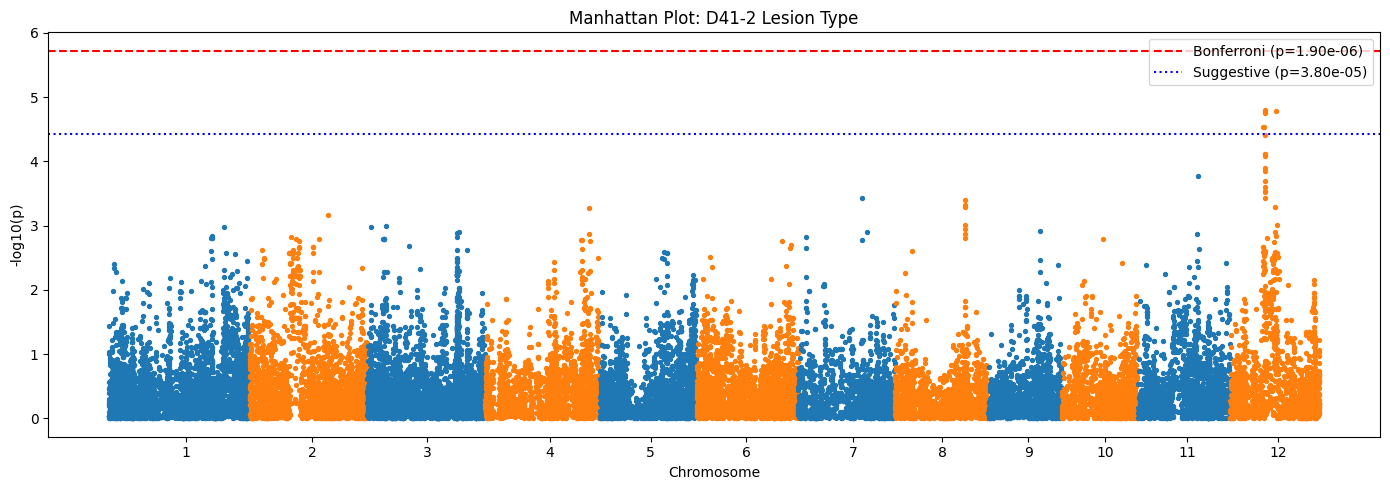

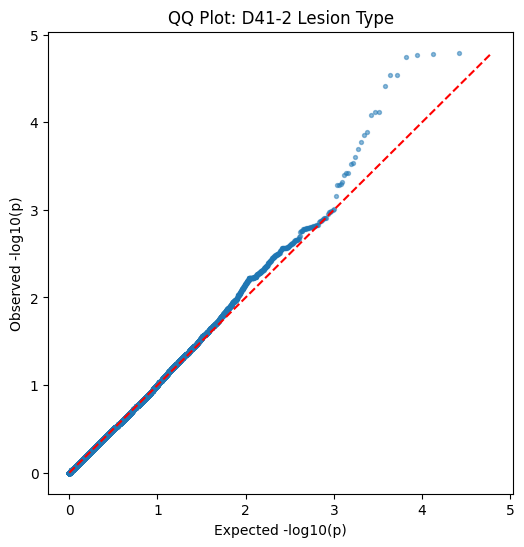

Genomic inflation factor (lambda_GC): 0.993


In [49]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# --- Manhattan plot ---
assoc_sorted = assoc.sort_values(['chr', 'ps']).reset_index(drop=True)
assoc_sorted['pos_cum'] = 0
offset = 0
chrom_centers = []
for chrom in sorted(assoc_sorted['chr'].unique()):
    mask = assoc_sorted['chr'] == chrom
    assoc_sorted.loc[mask, 'pos_cum'] = assoc_sorted.loc[mask, 'ps'] + offset
    chrom_centers.append((chrom, assoc_sorted.loc[mask, 'pos_cum'].mean()))
    offset = assoc_sorted.loc[mask, 'pos_cum'].max()

assoc_sorted['neg_log_p'] = -np.log10(assoc_sorted['p_wald'])

n_snps = len(assoc_sorted)
bonferroni = -np.log10(0.05 / n_snps)
suggestive = -np.log10(1 / n_snps)

colors = ['#1f77b4', '#ff7f0e']
fig, ax = plt.subplots(figsize=(14, 5))
for i, chrom in enumerate(sorted(assoc_sorted['chr'].unique())):
    sub = assoc_sorted[assoc_sorted['chr'] == chrom]
    ax.scatter(sub['pos_cum'], sub['neg_log_p'], c=colors[i % 2], s=8)

ax.axhline(bonferroni, color='red', linestyle='--', label=f'Bonferroni (p={0.05/n_snps:.2e})')
ax.axhline(suggestive, color='blue', linestyle=':', label=f'Suggestive (p={1/n_snps:.2e})')
ax.set_xticks([c[1] for c in chrom_centers])
ax.set_xticklabels([str(c[0]) for c in chrom_centers])
ax.set_xlabel('Chromosome')
ax.set_ylabel('-log10(p)')
ax.set_title('Manhattan Plot: D41-2 Lesion Type')
ax.legend()
plt.tight_layout()
plt.show()

# --- QQ plot + genomic inflation factor ---
observed = -np.log10(np.sort(assoc['p_wald']))
expected = -np.log10(np.linspace(1/len(assoc), 1, len(assoc)))

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(expected, observed, s=8, alpha=0.5)
max_val = max(expected.max(), observed.max())
ax.plot([0, max_val], [0, max_val], color='red', linestyle='--')
ax.set_xlabel('Expected -log10(p)')
ax.set_ylabel('Observed -log10(p)')
ax.set_title('QQ Plot: D41-2 Lesion Type')
plt.show()

chisq = stats.chi2.isf(assoc['p_wald'], df=1)
lambda_gc = np.median(chisq) / stats.chi2.ppf(0.5, df=1)
print(f"Genomic inflation factor (lambda_GC): {lambda_gc:.3f}")

In [50]:
chr12_hits = assoc[assoc['chr'] == 12].sort_values('p_wald').head(15)
chr12_hits[['chr', 'rs', 'ps', 'allele1', 'allele0', 'beta', 'p_wald']]


,chr,rs,ps,allele1,allele0,beta,p_wald
25378,12,id12004143,10761575,T,G,-0.998553,0.000016
25545,12,id12005070,14031807,G,A,-1.085495,0.000017
25397,12,id12004228,10864829,T,C,-1.014076,0.000017
25384,12,id12004183,10799415,G,A,-0.848146,0.000018
25352,12,id12004010,10393207,T,C,-0.919286,0.000029
25345,12,id12003996,10276913,T,C,-0.919286,0.000029
25379,12,id12004150,10763076,G,A,0.934539,0.000039
25395,12,id12004219,10861963,T,C,0.861808,0.000077
25380,12,id12004156,10764623,T,C,0.839319,0.000077
25382,12,id12004171,10767192,A,C,-0.876942,0.000082


## 9. Polished Plotting Style + Remaining GEMMA Runs

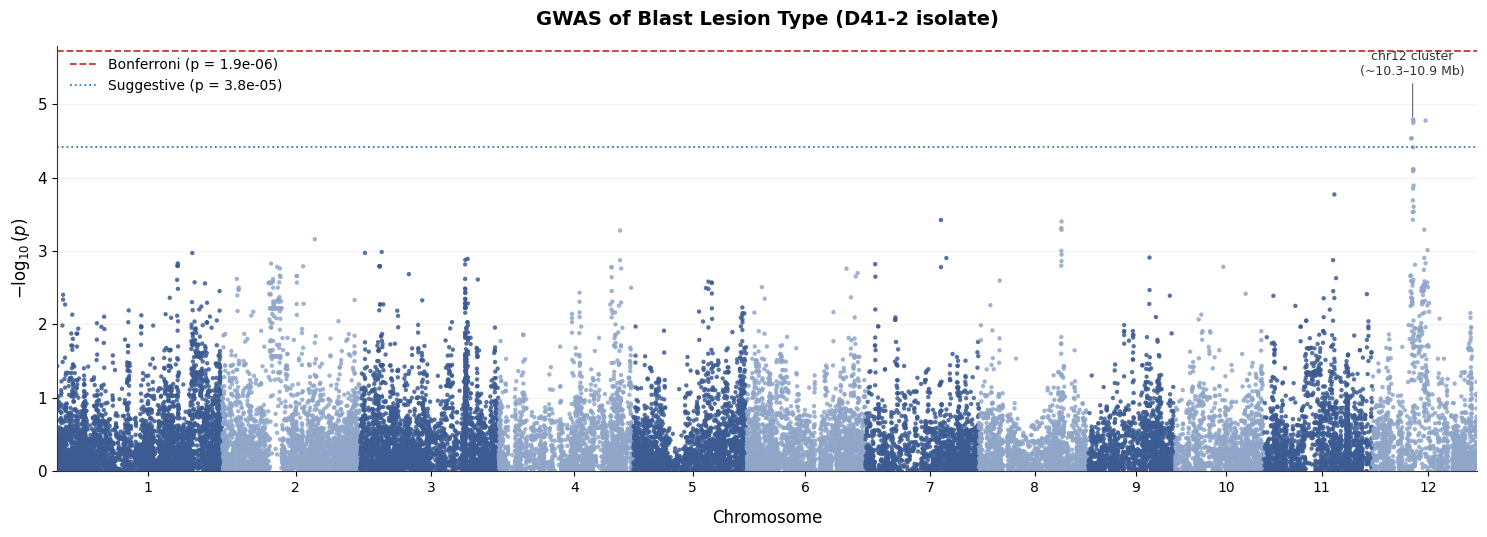

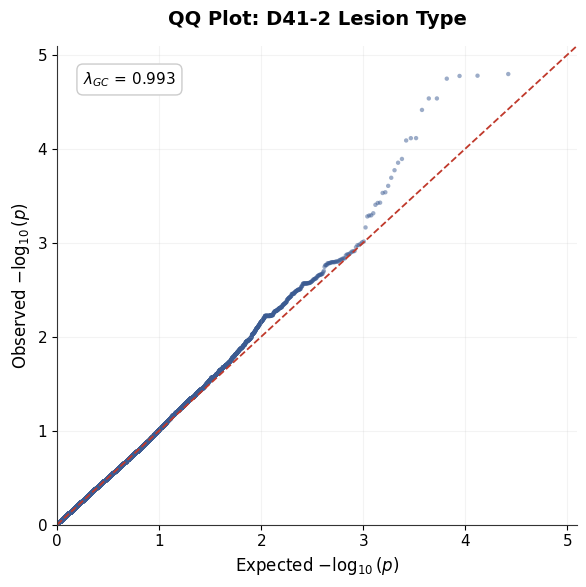

Genomic inflation factor (lambda_GC): 0.993


In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': '#333333',
    'figure.facecolor': 'white',
})

# --- Prep data ---
assoc_sorted = assoc.sort_values(['chr', 'ps']).reset_index(drop=True)
assoc_sorted['pos_cum'] = 0
offset = 0
chrom_centers = []
for chrom in sorted(assoc_sorted['chr'].unique()):
    mask = assoc_sorted['chr'] == chrom
    assoc_sorted.loc[mask, 'pos_cum'] = assoc_sorted.loc[mask, 'ps'] + offset
    chrom_centers.append((chrom, assoc_sorted.loc[mask, 'pos_cum'].mean()))
    offset = assoc_sorted.loc[mask, 'pos_cum'].max()
assoc_sorted['neg_log_p'] = -np.log10(assoc_sorted['p_wald'])

n_snps = len(assoc_sorted)
bonferroni = -np.log10(0.05 / n_snps)
suggestive = -np.log10(1 / n_snps)

# Two-tone palette, alternating per chromosome
palette = ['#3B5B92', '#8FA6C9']

fig, ax = plt.subplots(figsize=(15, 5.5))
for i, chrom in enumerate(sorted(assoc_sorted['chr'].unique())):
    sub = assoc_sorted[assoc_sorted['chr'] == chrom]
    ax.scatter(sub['pos_cum'], sub['neg_log_p'], c=palette[i % 2], s=10,
               alpha=0.85, edgecolors='none', rasterized=True)

ax.axhline(bonferroni, color='#C0392B', linestyle='--', linewidth=1.3,
           label=f'Bonferroni (p = {0.05/n_snps:.1e})')
ax.axhline(suggestive, color='#2980B9', linestyle=':', linewidth=1.3,
           label=f'Suggestive (p = {1/n_snps:.1e})')

# Annotate the chr12 cluster neutrally (position confirmed match still pending)
chr12_cluster_cum = assoc_sorted[(assoc_sorted['chr'] == 12) &
                                  (assoc_sorted['ps'].between(10_276_913, 10_902_721))]['pos_cum'].mean()
ax.annotate('chr12 cluster\n(~10.3–10.9 Mb)',
            xy=(chr12_cluster_cum, assoc_sorted['neg_log_p'].max()),
            xytext=(chr12_cluster_cum, assoc_sorted['neg_log_p'].max() + 0.6),
            ha='center', fontsize=9, color='#333333',
            arrowprops=dict(arrowstyle='-', color='#666666', lw=0.8))

ax.set_xticks([c[1] for c in chrom_centers])
ax.set_xticklabels([str(c[0]) for c in chrom_centers], fontsize=10)
ax.set_xlim(assoc_sorted['pos_cum'].min(), assoc_sorted['pos_cum'].max())
ax.set_ylim(0, assoc_sorted['neg_log_p'].max() + 1)
ax.set_xlabel('Chromosome', fontsize=12, labelpad=10)
ax.set_ylabel(r'$-\log_{10}(p)$', fontsize=12)
ax.set_title('GWAS of Blast Lesion Type (D41-2 isolate)', fontsize=14, fontweight='bold', pad=15)
ax.legend(frameon=False, loc='upper left', fontsize=10)
ax.grid(axis='y', linestyle='-', alpha=0.15)
plt.tight_layout()
plt.savefig(dataset_dir + '/manhattan_d41_2_LT.png', dpi=300, bbox_inches='tight')
plt.show()

# --- QQ plot ---
observed = -np.log10(np.sort(assoc['p_wald']))
expected = -np.log10(np.linspace(1/len(assoc), 1, len(assoc)))
chisq = stats.chi2.isf(assoc['p_wald'], df=1)
lambda_gc = np.median(chisq) / stats.chi2.ppf(0.5, df=1)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(expected, observed, s=10, alpha=0.5, color='#3B5B92', edgecolors='none')
max_val = max(expected.max(), observed.max()) + 0.3
ax.plot([0, max_val], [0, max_val], color='#C0392B', linestyle='--', linewidth=1.3)
ax.set_xlim(0, max_val)
ax.set_ylim(0, max_val)
ax.set_xlabel(r'Expected $-\log_{10}(p)$', fontsize=12)
ax.set_ylabel(r'Observed $-\log_{10}(p)$', fontsize=12)
ax.set_title('QQ Plot: D41-2 Lesion Type', fontsize=14, fontweight='bold', pad=15)
ax.text(0.05, 0.92, r'$\lambda_{GC}$' + f' = {lambda_gc:.3f}', transform=ax.transAxes,
        fontsize=11, bbox=dict(facecolor='white', edgecolor='#cccccc', boxstyle='round,pad=0.4'))
ax.grid(alpha=0.15)
plt.tight_layout()
plt.savefig(dataset_dir + '/qq_d41_2_LT.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Genomic inflation factor (lambda_GC): {lambda_gc:.3f}")

In [52]:
!./gemma -bfile "{dataset_dir}/sativa_qc_dedup" \
  -p "{dataset_dir}/gemma_phenotypes.txt" \
  -k "{dataset_dir}/sativa_kinship.cXX.txt" \
  -c "{dataset_dir}/gemma_covariates.txt" \
  -n 3 -lmm 4 \
  -o d41_2_DLA_gwas \
  -outdir "{dataset_dir}"

GEMMA 0.98.5 (2021-08-25) by Xiang Zhou, Pjotr Prins and team (C) 2012-2021
Reading Files ... 
## number of total individuals = 360
## number of analyzed individuals = 257
## number of covariates = 4
## number of phenotypes = 1
## number of total SNPs/var        =    30122
## number of analyzed SNPs         =    26294
Start Eigen-Decomposition...
pve estimate =0.341655
se(pve) =0.172619

**** INFO: Done.


In [53]:
!./gemma -bfile "{dataset_dir}/sativa_qc_dedup" \
  -p "{dataset_dir}/gemma_phenotypes.txt" \
  -k "{dataset_dir}/sativa_kinship.cXX.txt" \
  -c "{dataset_dir}/gemma_covariates.txt" \
  -n 4 -lmm 4 \
  -o d12yl_LT_gwas \
  -outdir "{dataset_dir}"

GEMMA 0.98.5 (2021-08-25) by Xiang Zhou, Pjotr Prins and team (C) 2012-2021
Reading Files ... 
## number of total individuals = 360
## number of analyzed individuals = 193
## number of covariates = 4
## number of phenotypes = 1
## number of total SNPs/var        =    30122
## number of analyzed SNPs         =    26469
Start Eigen-Decomposition...
pve estimate =0.881892
se(pve) =0.0615468

**** INFO: Done.


In [54]:
!./gemma -bfile "{dataset_dir}/sativa_qc_dedup" \
  -p "{dataset_dir}/gemma_phenotypes.txt" \
  -k "{dataset_dir}/sativa_kinship.cXX.txt" \
  -c "{dataset_dir}/gemma_covariates.txt" \
  -n 5 -lmm 4 \
  -o d12yl_DLA_gwas \
  -outdir "{dataset_dir}"

GEMMA 0.98.5 (2021-08-25) by Xiang Zhou, Pjotr Prins and team (C) 2012-2021
Reading Files ... 
## number of total individuals = 360
## number of analyzed individuals = 193
## number of covariates = 4
## number of phenotypes = 1
## number of total SNPs/var        =    30122
## number of analyzed SNPs         =    26469
Start Eigen-Decomposition...
pve estimate =0.295406
se(pve) =0.195417

**** INFO: Done.


## 10. Batch Plotting — Remaining Three Traits

In [55]:
def plot_gwas_results(assoc_path, trait_name, save_prefix):
    assoc = pd.read_csv(assoc_path, sep='\t')

    assoc_sorted = assoc.sort_values(['chr', 'ps']).reset_index(drop=True)
    assoc_sorted['pos_cum'] = 0
    offset = 0
    chrom_centers = []
    for chrom in sorted(assoc_sorted['chr'].unique()):
        mask = assoc_sorted['chr'] == chrom
        assoc_sorted.loc[mask, 'pos_cum'] = assoc_sorted.loc[mask, 'ps'] + offset
        chrom_centers.append((chrom, assoc_sorted.loc[mask, 'pos_cum'].mean()))
        offset = assoc_sorted.loc[mask, 'pos_cum'].max()
    assoc_sorted['neg_log_p'] = -np.log10(assoc_sorted['p_wald'])

    n_snps = len(assoc_sorted)
    bonferroni = -np.log10(0.05 / n_snps)
    suggestive = -np.log10(1 / n_snps)

    palette = ['#3B5B92', '#8FA6C9']
    fig, ax = plt.subplots(figsize=(15, 5.5))
    for i, chrom in enumerate(sorted(assoc_sorted['chr'].unique())):
        sub = assoc_sorted[assoc_sorted['chr'] == chrom]
        ax.scatter(sub['pos_cum'], sub['neg_log_p'], c=palette[i % 2], s=10,
                   alpha=0.85, edgecolors='none', rasterized=True)
    ax.axhline(bonferroni, color='#C0392B', linestyle='--', linewidth=1.3,
               label=f'Bonferroni (p = {0.05/n_snps:.1e})')
    ax.axhline(suggestive, color='#2980B9', linestyle=':', linewidth=1.3,
               label=f'Suggestive (p = {1/n_snps:.1e})')
    ax.set_xticks([c[1] for c in chrom_centers])
    ax.set_xticklabels([str(c[0]) for c in chrom_centers], fontsize=10)
    ax.set_xlim(assoc_sorted['pos_cum'].min(), assoc_sorted['pos_cum'].max())
    ax.set_ylim(0, assoc_sorted['neg_log_p'].max() + 1)
    ax.set_xlabel('Chromosome', fontsize=12, labelpad=10)
    ax.set_ylabel(r'$-\log_{10}(p)$', fontsize=12)
    ax.set_title(f'GWAS of {trait_name}', fontsize=14, fontweight='bold', pad=15)
    ax.legend(frameon=False, loc='upper left', fontsize=10)
    ax.grid(axis='y', linestyle='-', alpha=0.15)
    plt.tight_layout()
    plt.savefig(f'{dataset_dir}/manhattan_{save_prefix}.png', dpi=300, bbox_inches='tight')
    plt.show()

    observed = -np.log10(np.sort(assoc['p_wald']))
    expected = -np.log10(np.linspace(1/len(assoc), 1, len(assoc)))
    chisq = stats.chi2.isf(assoc['p_wald'], df=1)
    lambda_gc = np.median(chisq) / stats.chi2.ppf(0.5, df=1)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(expected, observed, s=10, alpha=0.5, color='#3B5B92', edgecolors='none')
    max_val = max(expected.max(), observed.max()) + 0.3
    ax.plot([0, max_val], [0, max_val], color='#C0392B', linestyle='--', linewidth=1.3)
    ax.set_xlim(0, max_val); ax.set_ylim(0, max_val)
    ax.set_xlabel(r'Expected $-\log_{10}(p)$', fontsize=12)
    ax.set_ylabel(r'Observed $-\log_{10}(p)$', fontsize=12)
    ax.set_title(f'QQ Plot: {trait_name}', fontsize=14, fontweight='bold', pad=15)
    ax.text(0.05, 0.92, r'$\lambda_{GC}$' + f' = {lambda_gc:.3f}', transform=ax.transAxes,
            fontsize=11, bbox=dict(facecolor='white', edgecolor='#cccccc', boxstyle='round,pad=0.4'))
    ax.grid(alpha=0.15)
    plt.tight_layout()
    plt.savefig(f'{dataset_dir}/qq_{save_prefix}.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"{trait_name}: lambda_GC = {lambda_gc:.3f}, top hit p = {assoc['p_wald'].min():.2e}")
    return assoc

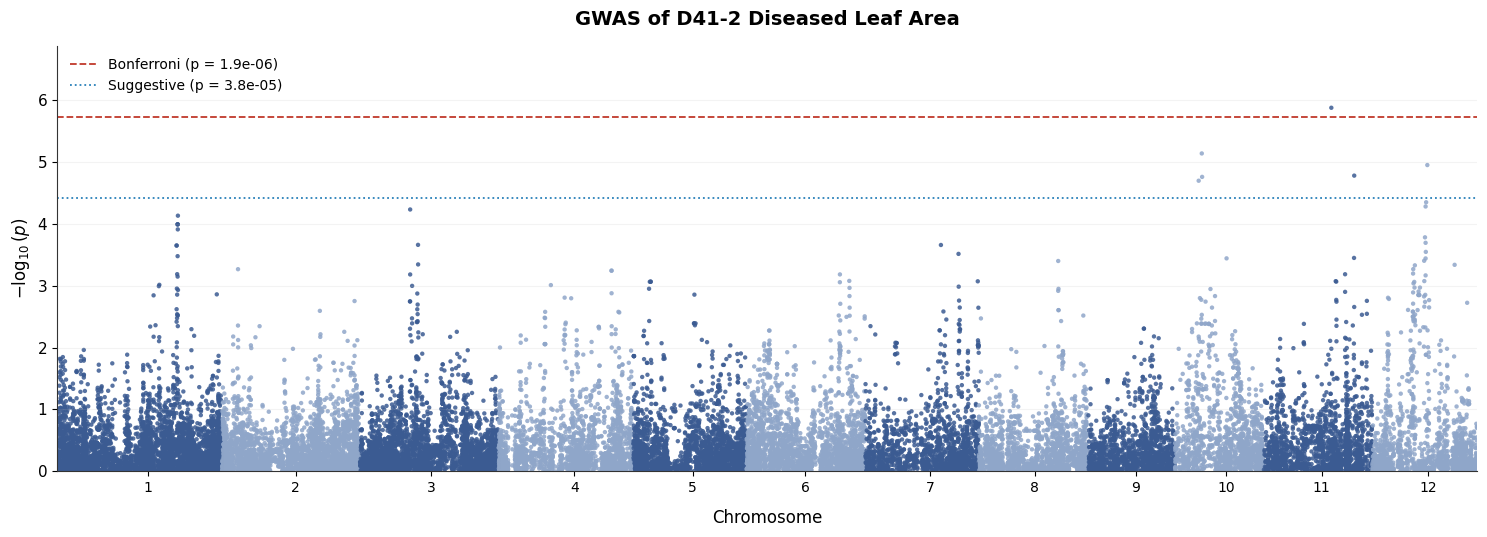

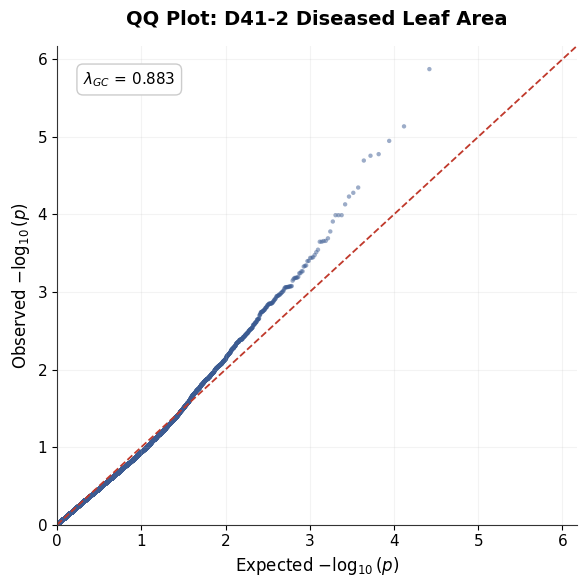

D41-2 Diseased Leaf Area: lambda_GC = 0.883, top hit p = 1.34e-06


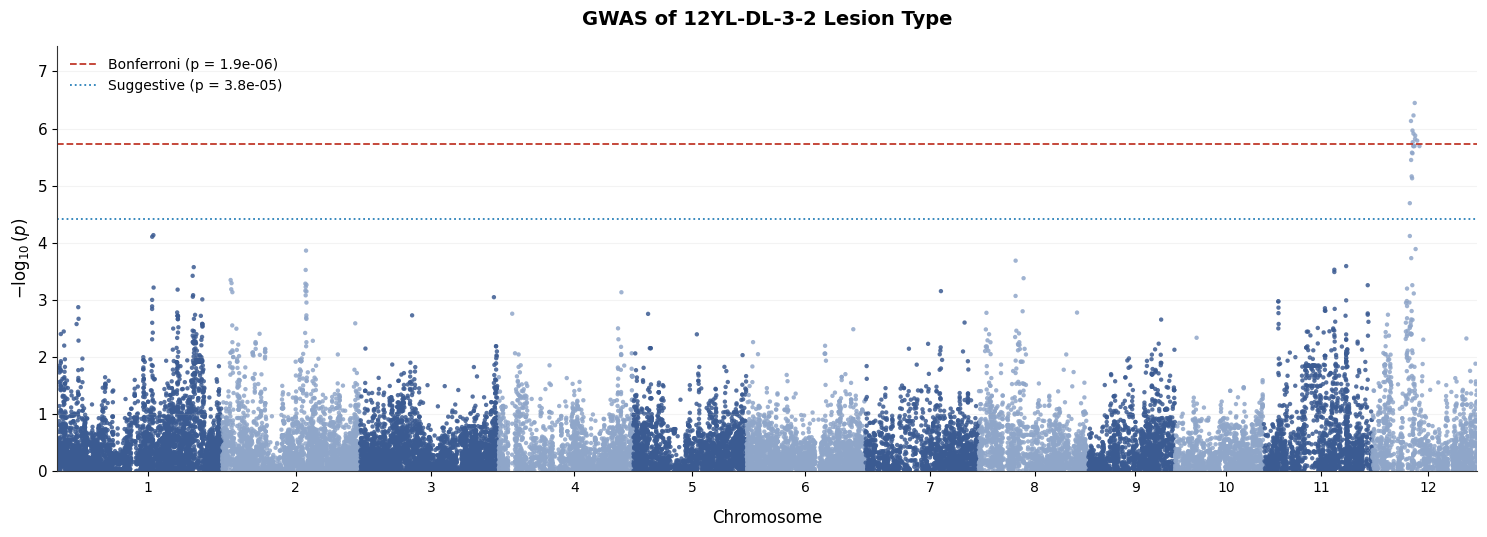

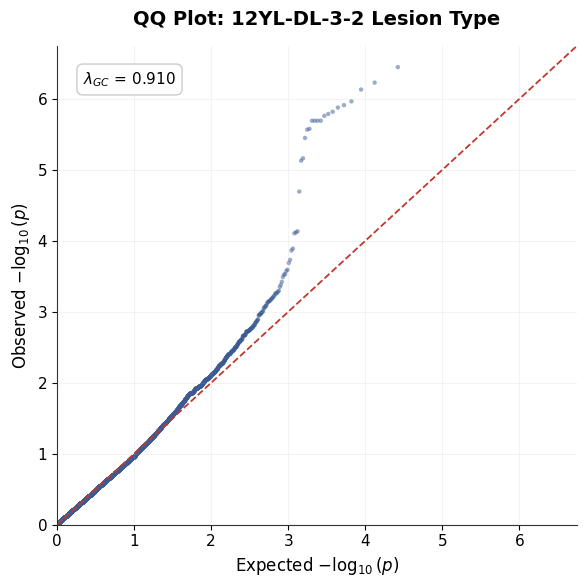

12YL-DL-3-2 Lesion Type: lambda_GC = 0.910, top hit p = 3.56e-07


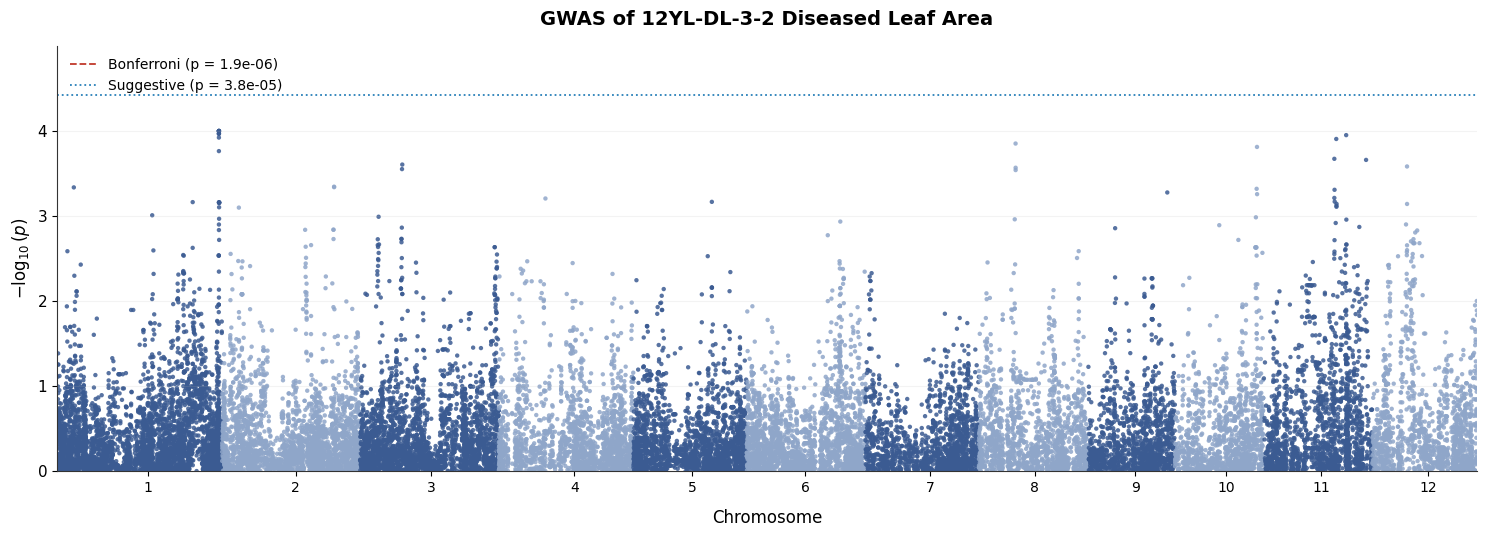

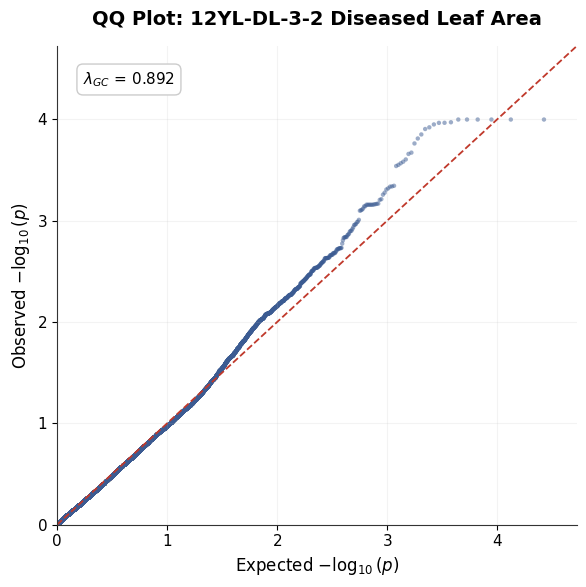

12YL-DL-3-2 Diseased Leaf Area: lambda_GC = 0.892, top hit p = 1.01e-04


In [56]:
assoc_d41_dla  = plot_gwas_results(dataset_dir + '/d41_2_DLA_gwas.assoc.txt', 'D41-2 Diseased Leaf Area', 'd41_2_DLA')
assoc_12yl_lt  = plot_gwas_results(dataset_dir + '/d12yl_LT_gwas.assoc.txt', '12YL-DL-3-2 Lesion Type', 'd12yl_LT')
assoc_12yl_dla = plot_gwas_results(dataset_dir + '/d12yl_DLA_gwas.assoc.txt', '12YL-DL-3-2 Diseased Leaf Area', 'd12yl_DLA')

In [57]:
print("12YL LT - chr12 top hits:")
print(assoc_12yl_lt[assoc_12yl_lt['chr'] == 12].sort_values('p_wald').head(15)[['ps', 'beta', 'p_wald']])

12YL LT - chr12 top hits:
             ps      beta        p_wald
25589  11190243 -1.867045  3.564628e-07
25570  10868316 -1.810480  5.894069e-07
25512  10208157 -1.781316  7.373310e-07
25538  10604192 -1.790951  1.082417e-06
25565  10860308 -1.739262  1.223321e-06
25603  11319589 -1.743941  1.322975e-06
25601  11267491 -1.732384  1.515460e-06
25611  11840177 -1.742386  1.627886e-06
25547  10668612 -1.686307  1.731376e-06
25584  11135070 -1.701941  2.028347e-06
25566  10861719 -1.701941  2.028347e-06
25634  12427840 -1.701941  2.028347e-06
25564  10859755 -1.701941  2.028347e-06
25533  10468515 -1.888196  2.638819e-06
25540  10604967 -1.674406  2.706870e-06


In [58]:
print("D41-2 DLA — chr11 top hits:")
print(assoc_d41_dla[assoc_d41_dla['chr'] == 11].sort_values('p_wald').head(10)[['ps', 'beta', 'p_wald']])

D41-2 DLA — chr11 top hits:
             ps      beta    p_wald
24052  17823963  4.516635  0.000001
24639  23814347  4.378619  0.000017
24636  23768147  3.600080  0.000357
24302  21425246  3.005458  0.000655
24179  18967086  3.765696  0.000848
24191  19111547 -3.638324  0.000862
24303  21428886  2.818678  0.001261
24192  19112616  3.150172  0.001699
24820  27126077  2.107136  0.001762
24196  19167805 -2.945333  0.001818


In [59]:
def get_significant_hits(assoc, trait_name):
    n_snps = len(assoc)
    suggestive = 1 / n_snps
    hits = assoc[assoc['p_wald'] <= suggestive].copy()
    hits['trait'] = trait_name
    return hits

all_hits = pd.concat([
    get_significant_hits(assoc, 'D41-2_LT'),
    get_significant_hits(assoc_d41_dla, 'D41-2_DLA'),
    get_significant_hits(assoc_12yl_lt, '12YL_LT'),
    get_significant_hits(assoc_12yl_dla, '12YL_DLA'),
])

all_hits_sorted = all_hits[['trait', 'chr', 'rs', 'ps', 'beta', 'p_wald']].sort_values(['chr', 'ps'])
print(f"{len(all_hits_sorted)} suggestive-or-better SNPs across all 4 traits")
all_hits_sorted.to_csv(dataset_dir + '/all_suggestive_hits.csv', index=False)
all_hits_sorted

31 suggestive-or-better SNPs across all 4 traits


,trait,chr,rs,ps,beta,p_wald
22122,D41-2_DLA,10,id10001923,6231500,-3.419638,2.024029e-05
22172,D41-2_DLA,10,id10002284,7044997,-3.675685,7.339002e-06
22174,D41-2_DLA,10,id10002294,7134484,-3.490267,1.754721e-05
24052,D41-2_DLA,11,id11006398,17823963,4.516635,1.342216e-06
24639,D41-2_DLA,11,id11009412,23814347,4.378619,1.674098e-05
25504,12YL_LT,12,id12003875,9906982,-1.613688,2.021835e-05
25512,12YL_LT,12,id12003973,10208157,-1.781316,7.373310e-07
25514,12YL_LT,12,ud12000654,10245978,-1.669482,3.546864e-06
25345,D41-2_LT,12,id12003996,10276913,-0.919286,2.925834e-05
25520,12YL_LT,12,id12004003,10385086,-1.644659,6.870038e-06


## 11. Candidate Gene Mapping (MSU7 Annotation)
All suggestive-or-better SNPs mapped to genes within a ±200 kb window (to absorb MSU6→MSU7 coordinate differences). Validated against the known resistance genes *Pita* (`LOC_Os12g18360`) and *Ptr/Pita2* (`LOC_Os12g18729`).

In [ ]:
!wget -q https://rice.uga.edu/pub/data/Eukaryotic_Projects/o_sativa/annotation_dbs/pseudomolecules/version_7.0/all.dir/all.gff3 -O "{dataset_dir}/msu7_annotation.gff3"
!ls -la "{dataset_dir}/msu7_annotation.gff3"
!head -20 "{dataset_dir}/msu7_annotation.gff3"


In [63]:
import pandas as pd
import re

gff_path = dataset_dir + '/msu7_annotation.gff3'
gff_cols = ['seqid', 'source', 'type', 'start', 'end', 'score', 'strand', 'frame', 'attributes']
gff = pd.read_csv(gff_path, sep='\t', comment='#', header=None, names=gff_cols,
                   dtype={'seqid': str}, low_memory=False)

genes = gff[gff['type'] == 'gene'].copy()
genes['chr_str'] = genes['seqid'].str.replace('Chr', '', regex=False)

dropped = (~genes['chr_str'].str.isnumeric()).sum()
print(f"Dropping {dropped} genes on unplaced/special contigs")

genes = genes[genes['chr_str'].str.isnumeric()].copy()
genes['chr'] = genes['chr_str'].astype(int)

def parse_attr(attr, key):
    m = re.search(f'{key}=([^;]+)', attr)
    return m.group(1) if m else None

genes['gene_id'] = genes['attributes'].apply(lambda a: parse_attr(a, 'ID'))
genes['note'] = genes['attributes'].apply(lambda a: parse_attr(a, 'Note'))

print(f"{len(genes)} genes loaded on chromosomes 1-12")
genes[['chr', 'start', 'end', 'gene_id', 'note']].head()

Dropping 185 genes on unplaced/special contigs
55801 genes loaded on chromosomes 1-12


,chr,start,end,gene_id,note
0,1,2903,10817,LOC_Os01g01010,TBC%20domain%20containing%20protein%2C%20expre...
54,1,11218,12435,LOC_Os01g01019,expressed%20protein
62,1,12648,15915,LOC_Os01g01030,monocopper%20oxidase%2C%20putative%2C%20expressed
76,1,16292,20323,LOC_Os01g01040,expressed%20protein
141,1,22841,26971,LOC_Os01g01050,R3H%20domain%20containing%20protein%2C%20expre...


In [64]:
window = 200_000  # generous window, given the MSU6 vs MSU7 coordinate caveat

def nearest_genes(chr_, pos, window=window):
    candidates = genes[(genes['chr'] == chr_) &
                        (genes['end'] >= pos - window) &
                        (genes['start'] <= pos + window)].copy()
    candidates['distance'] = candidates.apply(
        lambda r: 0 if r['start'] <= pos <= r['end'] else min(abs(r['start']-pos), abs(r['end']-pos)),
        axis=1
    )
    return candidates.sort_values('distance')[['gene_id', 'start', 'end', 'distance', 'note']]

results = []
for _, row in all_hits_sorted.iterrows():
    for _, g in nearest_genes(row['chr'], row['ps']).iterrows():
        results.append({
            'trait': row['trait'], 'chr': row['chr'], 'snp_pos': row['ps'], 'p_wald': row['p_wald'],
            'gene_id': g['gene_id'], 'gene_start': g['start'], 'gene_end': g['end'],
            'distance_bp': g['distance'], 'note': g['note']
        })

gene_hits = pd.DataFrame(results)
print(f"{len(gene_hits)} SNP-gene pairs found within {window:,} bp")
gene_hits.sort_values(['chr', 'snp_pos', 'distance_bp']).to_csv(dataset_dir + '/gene_hits.csv', index=False)
gene_hits.sort_values(['chr', 'snp_pos', 'distance_bp'])

1693 SNP-gene pairs found within 200,000 bp


,trait,chr,snp_pos,p_wald,gene_id,gene_start,gene_end,distance_bp,note
0,D41-2_DLA,10,6231500,0.000020,LOC_Os10g11230,6228123,6231823,0,transposon%20protein%2C%20putative%2C%20CACTA%...
1,D41-2_DLA,10,6231500,0.000020,LOC_Os10g11240,6233625,6236688,2125,expressed%20protein
2,D41-2_DLA,10,6231500,0.000020,LOC_Os10g11220,6222920,6226152,5348,transposon%20protein%2C%20putative%2C%20CACTA%...
3,D41-2_DLA,10,6231500,0.000020,LOC_Os10g11250,6237459,6242030,5959,transposon%20protein%2C%20putative%2C%20CACTA%...
4,D41-2_DLA,10,6231500,0.000020,LOC_Os10g11210,6218385,6221717,9783,transposon%20protein%2C%20putative%2C%20CACTA%...
...,...,...,...,...,...,...,...,...,...
1688,D41-2_DLA,12,14487618,0.000011,LOC_Os12g25400,14652534,14652969,164916,expressed%20protein
1689,D41-2_DLA,12,14487618,0.000011,LOC_Os12g24930,14318958,14320764,166854,retrotransposon%20protein%2C%20putative%2C%20T...
1690,D41-2_DLA,12,14487618,0.000011,LOC_Os12g25409,14660161,14660849,172543,expressed%20protein
1691,D41-2_DLA,12,14487618,0.000011,LOC_Os12g24920,14310008,14314533,173085,retrotransposon%2C%20putative%2C%20centromere-...


In [65]:
gene_hits[gene_hits['gene_id'].isin(['LOC_Os12g18360', 'LOC_Os12g18729'])]

,trait,chr,snp_pos,p_wald,gene_id,gene_start,gene_end,distance_bp,note
678,12YL_LT,12,10468515,2.638819e-06,LOC_Os12g18360,10606359,10612068,137844,NB-ARC%20domain%20containing%20protein%2C%20ex...
719,12YL_LT,12,10507291,7.413696e-06,LOC_Os12g18360,10606359,10612068,99068,NB-ARC%20domain%20containing%20protein%2C%20ex...
750,12YL_LT,12,10604192,1.082417e-06,LOC_Os12g18360,10606359,10612068,2167,NB-ARC%20domain%20containing%20protein%2C%20ex...
804,12YL_LT,12,10604967,2.706870e-06,LOC_Os12g18360,10606359,10612068,1392,NB-ARC%20domain%20containing%20protein%2C%20ex...
876,12YL_LT,12,10668612,1.731376e-06,LOC_Os12g18360,10606359,10612068,56544,NB-ARC%20domain%20containing%20protein%2C%20ex...
906,12YL_LT,12,10668612,1.731376e-06,LOC_Os12g18729,10822534,10833768,153922,expressed%20protein
933,D41-2_LT,12,10761575,1.609731e-05,LOC_Os12g18729,10822534,10833768,60959,expressed%20protein
955,D41-2_LT,12,10761575,1.609731e-05,LOC_Os12g18360,10606359,10612068,149507,NB-ARC%20domain%20containing%20protein%2C%20ex...
971,D41-2_LT,12,10799415,1.802962e-05,LOC_Os12g18729,10822534,10833768,23119,expressed%20protein
1013,D41-2_LT,12,10799415,1.802962e-05,LOC_Os12g18360,10606359,10612068,187347,NB-ARC%20domain%20containing%20protein%2C%20ex...


In [66]:
top_candidates = gene_hits[
    (gene_hits['gene_id'].isin(['LOC_Os12g18360', 'LOC_Os12g18729'])) |
    ((gene_hits['chr'] == 10) & (gene_hits['distance_bp'] == 0)) |
    ((gene_hits['chr'] == 11) & (gene_hits['distance_bp'] < 5000))
].sort_values('distance_bp').drop_duplicates('gene_id')

top_candidates[['gene_id', 'chr', 'trait', 'distance_bp', 'p_wald', 'note']]

,gene_id,chr,trait,distance_bp,p_wald,note
0,LOC_Os10g11230,10,D41-2_DLA,0,0.000020,transposon%20protein%2C%20putative%2C%20CACTA%...
120,LOC_Os10g12770,10,D41-2_DLA,0,0.000018,retrotransposon%20protein%2C%20putative%2C%20T...
804,LOC_Os12g18360,12,12YL_LT,1392,0.000003,NB-ARC%20domain%20containing%20protein%2C%20ex...
232,LOC_Os11g39950,11,D41-2_DLA,2023,0.000017,retrotransposon%20protein%2C%20putative%2C%20T...
179,LOC_Os11g30600,11,D41-2_DLA,3605,0.000001,hypothetical%20protein
971,LOC_Os12g18729,12,D41-2_LT,23119,0.000018,expressed%20protein


## 12. Summary Figures

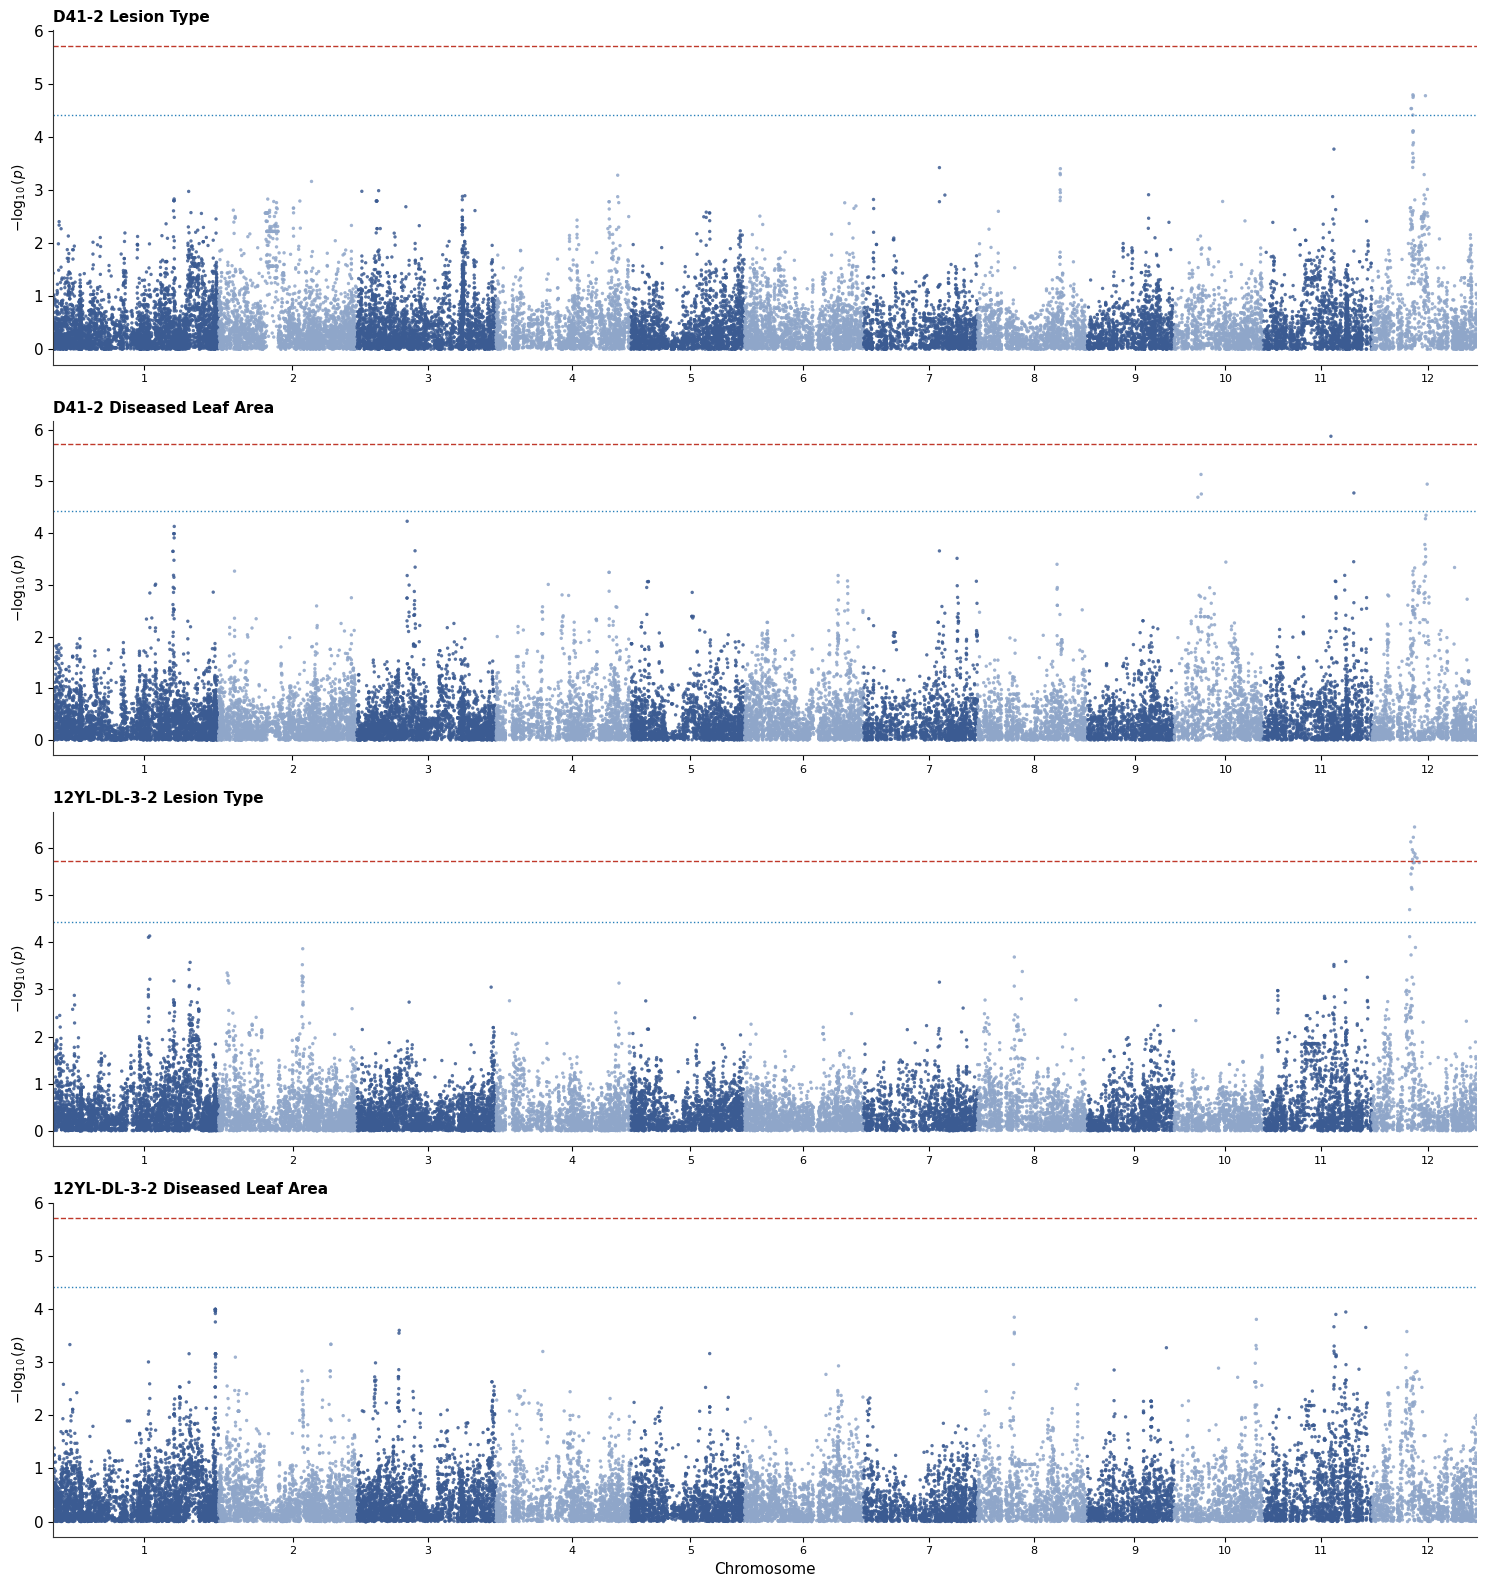

In [67]:
import matplotlib.pyplot as plt

traits = [
    (assoc, 'D41-2 Lesion Type'),
    (assoc_d41_dla, 'D41-2 Diseased Leaf Area'),
    (assoc_12yl_lt, '12YL-DL-3-2 Lesion Type'),
    (assoc_12yl_dla, '12YL-DL-3-2 Diseased Leaf Area'),
]

fig, axes = plt.subplots(4, 1, figsize=(15, 16), sharex=False)
palette = ['#3B5B92', '#8FA6C9']

for ax, (df, title) in zip(axes, traits):
    d = df.sort_values(['chr', 'ps']).reset_index(drop=True)
    d['pos_cum'] = 0
    offset = 0
    chrom_centers = []
    for chrom in sorted(d['chr'].unique()):
        mask = d['chr'] == chrom
        d.loc[mask, 'pos_cum'] = d.loc[mask, 'ps'] + offset
        chrom_centers.append((chrom, d.loc[mask, 'pos_cum'].mean()))
        offset = d.loc[mask, 'pos_cum'].max()
    d['neg_log_p'] = -np.log10(d['p_wald'])

    n_snps = len(d)
    bonferroni = -np.log10(0.05 / n_snps)
    suggestive = -np.log10(1 / n_snps)

    for i, chrom in enumerate(sorted(d['chr'].unique())):
        sub = d[d['chr'] == chrom]
        ax.scatter(sub['pos_cum'], sub['neg_log_p'], c=palette[i % 2], s=6,
                   alpha=0.85, edgecolors='none', rasterized=True)

    ax.axhline(bonferroni, color='#C0392B', linestyle='--', linewidth=1)
    ax.axhline(suggestive, color='#2980B9', linestyle=':', linewidth=1)
    ax.set_xticks([c[1] for c in chrom_centers])
    ax.set_xticklabels([str(c[0]) for c in chrom_centers], fontsize=8)
    ax.set_ylabel(r'$-\log_{10}(p)$', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold', loc='left')
    ax.set_xlim(d['pos_cum'].min(), d['pos_cum'].max())

axes[-1].set_xlabel('Chromosome', fontsize=11)
plt.tight_layout()
plt.savefig(dataset_dir + '/manhattan_all_traits_overview.png', dpi=300, bbox_inches='tight')
plt.show()

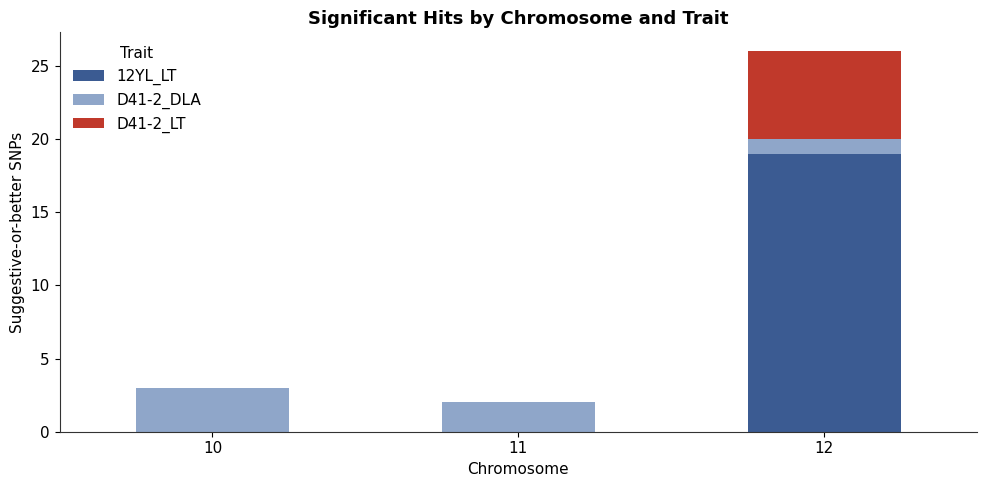

In [68]:

summary = all_hits_sorted.groupby(['chr', 'trait']).size().unstack(fill_value=0)
summary = summary.reindex(sorted(summary.index))

fig, ax = plt.subplots(figsize=(10, 5))
summary.plot(kind='bar', stacked=True, ax=ax,
             color=['#3B5B92', '#8FA6C9', '#C0392B', '#E8A87C'][:summary.shape[1]])

ax.set_xlabel('Chromosome', fontsize=11)
ax.set_ylabel('Suggestive-or-better SNPs', fontsize=11)
ax.set_title('Significant Hits by Chromosome and Trait', fontsize=13, fontweight='bold')
ax.legend(title='Trait', frameon=False)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(dataset_dir + '/hits_summary_by_chromosome.png', dpi=300, bbox_inches='tight')
plt.show()

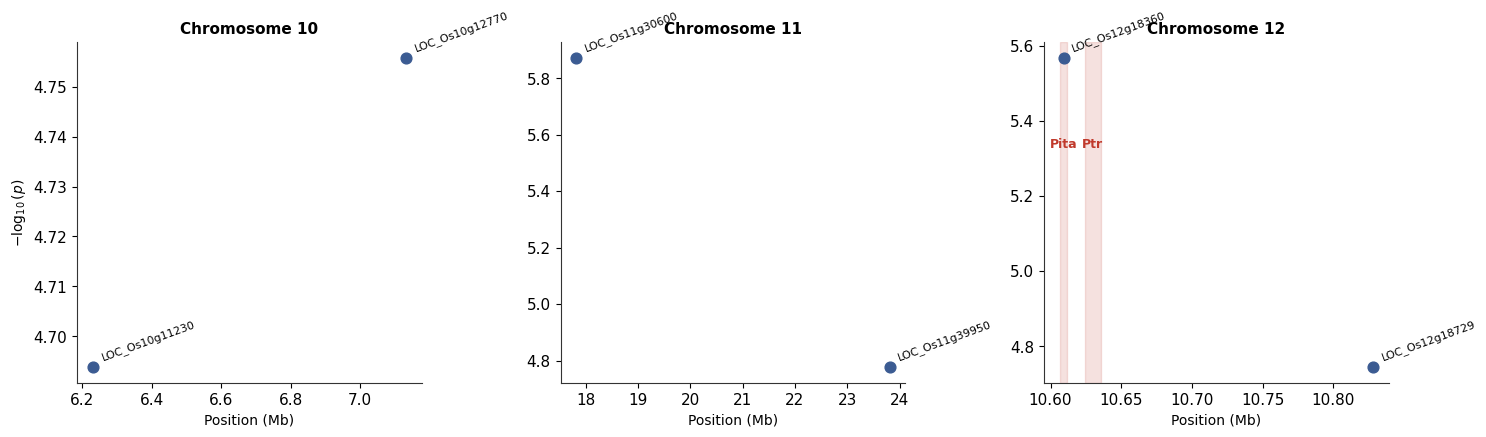

In [69]:

known_genes = {12: [('Pita', 10_606_359, 10_611_917), ('Ptr', 10_624_037, 10_635_373)]}

chrs = sorted(top_candidates['chr'].unique())
fig, axes = plt.subplots(1, len(chrs), figsize=(5*len(chrs), 4.5), squeeze=False)
axes = axes[0]

for ax, chrom in zip(axes, chrs):
    sub = top_candidates[top_candidates['chr'] == chrom].copy()
    sub['mid_pos'] = (sub['gene_start'] + sub['gene_end']) / 2 / 1e6
    sub['neg_log_p'] = -np.log10(sub['p_wald'])

    ax.scatter(sub['mid_pos'], sub['neg_log_p'], color='#3B5B92', s=60, zorder=3)
    for _, row in sub.iterrows():
        ax.annotate(row['gene_id'], (row['mid_pos'], row['neg_log_p']),
                    textcoords="offset points", xytext=(5, 5), fontsize=8, rotation=20)

    for name, start, end in known_genes.get(chrom, []):
        ax.axvspan(start/1e6, end/1e6, color='#C0392B', alpha=0.15)
        ax.text((start+end)/2/1e6, ax.get_ylim()[1]*0.95, name, color='#C0392B',
                ha='center', fontsize=9, fontweight='bold')

    ax.set_title(f'Chromosome {chrom}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Position (Mb)', fontsize=10)
    ax.set_ylabel(r'$-\log_{10}(p)$' if chrom == chrs[0] else '', fontsize=10)

plt.tight_layout()
plt.savefig(dataset_dir + '/candidate_genes_by_chromosome.png', dpi=300, bbox_inches='tight')
plt.show()

---
*Full results, all figures, and result tables: see [`results/`](../results/) and the main [README](../README.md).*